# Оптимизация производственных расходов металлургического комбината «Стальная птица» 

Металлургическому комбинату «Стальная птица» для имитации технологического процесса (с целью уменьшения потребления электроэнергии на этапе обработки стали) необходимо разработать модель МО, предсказывающую температуру сплава

Работа над проектом будет выполняться в несколько этапов:
- подключение к базе данных и изучение общей информации о данных;
- предобработка данных;
- исследовательский анализ данных;
- объединение данных;
- подготовка данных для модели МО;
- инициализация и обучение моделей МО с различными гиперпараметрами
- тестирование лучшей модели

**Описание данных**
1. **steel.data_arc**:
   - key — номер партии;
   - BeginHeat — время начала нагрева;
   - EndHeat — время окончания нагрева;
   - ActivePower — значение активной мощности;
   - ReactivePower — значение реактивной мощности
2. **steel.data_bulk**:
   - key — номер партии;
   - Bulk1 … Bulk15 — объём подаваемого материала (Пропуск означает, что материал не добавляли в партию).
3. **steel.data_bulk_time**:
   - key — номер партии;
   - Bulk1 … Bulk15 — время подачи материала.
4. **steel.data_gas**:
   - key — номер партии;
   - gas — объём подаваемого газа.
5. **steel.data_temp**:
   - key — номер партии;
   - MesaureTime — время замера.
   - <span style='color:green;'>Temperature — значение температуры (**Целевой признак — последняя температура партии**)</span>
6. **steel.data_wire**:
   - key — номер партии;
   - Wire1 … Wire9 — объём подаваемых проволочных материалов (Пропуск означает, что материал не добавляли в эту партию)
7. **steel.data_wire_time**:
   - key — номер партии;
   - Wire1 … Wire9 — время подачи проволочных материалов.

In [1]:
import copy
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
from scipy.stats.mstats import winsorize
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sqlalchemy import create_engine, inspect, text
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor

import phik
from phik.report import plot_correlation_matrix

In [2]:
# скрытие пердупреждений
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [3]:
# отображение всех столбцов
pd.set_option('display.max_columns', None)

In [4]:
# путь к БД
path_to_db = 'ds-plus-final.db'

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
RANDOM_STATE=300326

## Подключение к БД и изучение общей информации

In [7]:
# подключение к БД
engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

# проверка подключения
try:
    with engine.connect():
        print('успешное подключение')
except Exception as e:
    print(f'ошибка подключения: {e}')

успешное подключение


In [8]:
# таблицы БД
inspector = inspect(engine)
tables = inspector.get_table_names()
print("Список таблиц:")
for table in tables:
    print(f"- {table}")

Список таблиц:
- contract
- data_arc
- data_bulk
- data_bulk_time
- data_gas
- data_temp
- data_wire
- data_wire_time
- internet
- personal
- phone


In [9]:
# список необходимых таблиц
tables = ['data_arc', 'data_bulk', 'data_bulk_time', 
          'data_gas', 'data_temp', 'data_wire', 'data_wire_time']

# количество пропусков по столбцам таблиц
with engine.connect() as conn:
    for table_name in tables:
        print('\n')
        print(f"Таблица: \033[1m{table_name}\033[0m")
        
        columns = inspector.get_columns(table_name)
        
        for col in columns:
            col_name = col['name']
            try:
                query = text(f'''
                    SELECT 
                        COUNT(*) as total_rows,
                        COUNT("{col_name}") as non_null,
                        COUNT(*) - COUNT("{col_name}") as null_count
                    FROM {table_name}
                ''')
                result = conn.execute(query).first()
                
                total_rows = result[0]
                null_count = result[2]
                null_percentage = (null_count / total_rows * 100) if total_rows > 0 else 0
                
                print(f'{col_name:20} количество пропусков: {null_count:6} ({null_percentage:.2f}%)')
            except Exception as e:
                print(f'{col_name:10} ошибка: {e}')



Таблица: data_arc
key                  количество пропусков:      0 (0.00%)
Начало нагрева дугой количество пропусков:      0 (0.00%)
Конец нагрева дугой  количество пропусков:      0 (0.00%)
Активная мощность    количество пропусков:      0 (0.00%)
Реактивная мощность  количество пропусков:      0 (0.00%)


Таблица: data_bulk
key                  количество пропусков:      0 (0.00%)
Bulk 1               количество пропусков:   2877 (91.95%)
Bulk 2               количество пропусков:   3107 (99.30%)
Bulk 3               количество пропусков:   1831 (58.52%)
Bulk 4               количество пропусков:   2115 (67.59%)
Bulk 5               количество пропусков:   3052 (97.54%)
Bulk 6               количество пропусков:   2553 (81.59%)
Bulk 7               количество пропусков:   3104 (99.20%)
Bulk 8               количество пропусков:   3128 (99.97%)
Bulk 9               количество пропусков:   3110 (99.39%)
Bulk 10              количество пропусков:   2953 (94.38%)
Bulk 11              

### Преобразование данных в датафреймы

In [10]:
# инициализация датафреймов из таблиц БД
data_arc = pd.read_sql('SELECT * FROM data_arc', engine)

data_bulk = pd.read_sql('SELECT * FROM data_bulk', engine)

data_bulk_time = pd.read_sql('SELECT * FROM data_bulk_time', engine)

data_gas = pd.read_sql('SELECT * FROM data_gas', engine)

data_temp = pd.read_sql('SELECT * FROM data_temp', engine)

data_wire = pd.read_sql('SELECT * FROM data_wire', engine)

data_wire_time = pd.read_sql('SELECT * FROM data_wire_time', engine)

In [11]:
display(data_arc.head(3))
data_arc.info()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   key                   14876 non-null  int64  
 1   Начало нагрева дугой  14876 non-null  object 
 2   Конец нагрева дугой   14876 non-null  object 
 3   Активная мощность     14876 non-null  float64
 4   Реактивная мощность   14876 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 581.2+ KB


In [12]:
display(data_bulk.head(3))
data_bulk.info()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,None,None,None,None,None,None,None,206.0,None,150.0,154.0
1,2,NaN,NaN,NaN,73.0,None,None,None,None,None,None,None,206.0,None,149.0,154.0
2,3,NaN,NaN,NaN,34.0,None,None,None,None,None,None,None,205.0,None,152.0,153.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   key      3129 non-null   int64  
 1   Bulk 1   252 non-null    float64
 2   Bulk 2   22 non-null     float64
 3   Bulk 3   1298 non-null   float64
 4   Bulk 4   1014 non-null   float64
 5   Bulk 5   77 non-null     object 
 6   Bulk 6   576 non-null    object 
 7   Bulk 7   25 non-null     object 
 8   Bulk 8   1 non-null      object 
 9   Bulk 9   19 non-null     object 
 10  Bulk 10  176 non-null    object 
 11  Bulk 11  177 non-null    object 
 12  Bulk 12  2450 non-null   object 
 13  Bulk 13  18 non-null     object 
 14  Bulk 14  2806 non-null   object 
 15  Bulk 15  2248 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 391.3+ KB


In [13]:
display(data_bulk_time.head(3))
data_bulk_time.info()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,None,None,None,2019-05-03 11:28:48,None,None,None,None,None,None,None,2019-05-03 11:24:31,None,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,None,None,None,2019-05-03 11:36:50,None,None,None,None,None,None,None,2019-05-03 11:53:30,None,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,None,None,None,2019-05-03 12:32:39,None,None,None,None,None,None,None,2019-05-03 12:27:13,None,2019-05-03 12:21:01,2019-05-03 12:16:16


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   key      3129 non-null   int64 
 1   Bulk 1   252 non-null    object
 2   Bulk 2   22 non-null     object
 3   Bulk 3   1298 non-null   object
 4   Bulk 4   1014 non-null   object
 5   Bulk 5   77 non-null     object
 6   Bulk 6   576 non-null    object
 7   Bulk 7   25 non-null     object
 8   Bulk 8   1 non-null      object
 9   Bulk 9   19 non-null     object
 10  Bulk 10  176 non-null    object
 11  Bulk 11  177 non-null    object
 12  Bulk 12  2450 non-null   object
 13  Bulk 13  18 non-null     object
 14  Bulk 14  2806 non-null   object
 15  Bulk 15  2248 non-null   object
dtypes: int64(1), object(15)
memory usage: 391.3+ KB


In [14]:
display(data_gas.head(3))
data_gas.info()

,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3239 non-null   int64  
 1   Газ 1   3239 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 50.7 KB


In [15]:
display(data_temp.head(3))
data_temp.info()

,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   key           18092 non-null  int64 
 1   Время замера  18092 non-null  object
 2   Температура   14665 non-null  object
dtypes: int64(1), object(2)
memory usage: 424.2+ KB


In [16]:
display(data_wire.head(3))
data_wire.info()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,None,None,None,None,None,None,None,None
1,2,96.052315,None,None,None,None,None,None,None,None
2,3,91.160157,None,None,None,None,None,None,None,None


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3055 non-null   float64
 2   Wire 2  1079 non-null   object 
 3   Wire 3  63 non-null     object 
 4   Wire 4  14 non-null     object 
 5   Wire 5  1 non-null      object 
 6   Wire 6  73 non-null     object 
 7   Wire 7  11 non-null     object 
 8   Wire 8  19 non-null     object 
 9   Wire 9  29 non-null     object 
dtypes: float64(1), int64(1), object(8)
memory usage: 240.8+ KB


In [18]:
display(data_wire_time.head(3))
data_wire_time.info()

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

По результатам изучения общей информации о данных:
- проведено подключение к БД (присутствуют все заявленные таблицы)
- во всех таблицах, кроме ` data_arc` и ` data_gas` обнаружены пропуски (будут изучены и обработаны на этапе предобработки данных) (возможно присутствуют дубликаты, которые также будут обработаны на этапе предобработки)


## Предобработка данных 

На данном этапе будет проведена работа по:
- изменению некорректных типов данных столбцов с датой (приведем к типу datetime);
- значения NaN таблиц `data_bulk.`, `data_wire` заменим на 0 и изменим тип данных на float;
- столбец `Температура` таблицы `data_temp` изменим на int

In [17]:
# изменение типа данных таблицы data_arc
data_arc_cols = ['Начало нагрева дугой', 'Конец нагрева дугой']

for col in data_arc_cols:
    data_arc[col] = pd.to_datetime(data_arc[col], errors='coerce')

In [18]:
data_arc.info()
print('количество строк дубликатов -', data_arc.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14876 entries, 0 to 14875
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   key                   14876 non-null  int64         
 1   Начало нагрева дугой  14876 non-null  datetime64[ns]
 2   Конец нагрева дугой   14876 non-null  datetime64[ns]
 3   Активная мощность     14876 non-null  float64       
 4   Реактивная мощность   14876 non-null  float64       
dtypes: datetime64[ns](2), float64(2), int64(1)
memory usage: 581.2 KB
количество строк дубликатов - 0


In [19]:
data_arc.isna().sum()

key                     0
Начало нагрева дугой    0
Конец нагрева дугой     0
Активная мощность       0
Реактивная мощность     0
dtype: int64

In [20]:
# изменение типа данных таблицы data_bulk
data_bulk_columns = [col for col in data_bulk.columns if col != 'key']

for col in data_bulk_columns:
   data_bulk[col] = pd.to_numeric(data_bulk[col]).fillna(0).astype(int)

In [21]:
data_bulk.info()
print('количество строк дубликатов -', data_bulk.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   key      3129 non-null   int64
 1   Bulk 1   3129 non-null   int64
 2   Bulk 2   3129 non-null   int64
 3   Bulk 3   3129 non-null   int64
 4   Bulk 4   3129 non-null   int64
 5   Bulk 5   3129 non-null   int64
 6   Bulk 6   3129 non-null   int64
 7   Bulk 7   3129 non-null   int64
 8   Bulk 8   3129 non-null   int64
 9   Bulk 9   3129 non-null   int64
 10  Bulk 10  3129 non-null   int64
 11  Bulk 11  3129 non-null   int64
 12  Bulk 12  3129 non-null   int64
 13  Bulk 13  3129 non-null   int64
 14  Bulk 14  3129 non-null   int64
 15  Bulk 15  3129 non-null   int64
dtypes: int64(16)
memory usage: 391.3 KB
количество строк дубликатов - 0


In [22]:
# изменение типа данных таблицы data_bulk_time и data_wire_time
time_columns =  [col for col in list(data_bulk_time.columns)\
                 + list(data_wire_time.columns) if col != 'key']

for col in time_columns:
    if  col in data_bulk_time:
        data_bulk_time[col] = pd.to_datetime(data_bulk_time[col], errors='coerce')
    else:
        data_wire_time[col] = pd.to_datetime(data_wire_time[col], errors='coerce')

In [23]:
data_bulk_time.info()
print('количество строк дубликатов -', data_bulk_time.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   key      3129 non-null   int64         
 1   Bulk 1   252 non-null    datetime64[ns]
 2   Bulk 2   22 non-null     datetime64[ns]
 3   Bulk 3   1298 non-null   datetime64[ns]
 4   Bulk 4   1014 non-null   datetime64[ns]
 5   Bulk 5   77 non-null     datetime64[ns]
 6   Bulk 6   576 non-null    datetime64[ns]
 7   Bulk 7   25 non-null     datetime64[ns]
 8   Bulk 8   1 non-null      datetime64[ns]
 9   Bulk 9   19 non-null     datetime64[ns]
 10  Bulk 10  176 non-null    datetime64[ns]
 11  Bulk 11  177 non-null    datetime64[ns]
 12  Bulk 12  2450 non-null   datetime64[ns]
 13  Bulk 13  18 non-null     datetime64[ns]
 14  Bulk 14  2806 non-null   datetime64[ns]
 15  Bulk 15  2248 non-null   datetime64[ns]
dtypes: datetime64[ns](15), int64(1)
memory usage: 391.3 KB
количество строк дублик

In [24]:
data_wire_time.info()
print('количество строк дубликатов -', data_wire_time.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   key     3081 non-null   int64         
 1   Wire 1  3055 non-null   datetime64[ns]
 2   Wire 2  1079 non-null   datetime64[ns]
 3   Wire 3  63 non-null     datetime64[ns]
 4   Wire 4  14 non-null     datetime64[ns]
 5   Wire 5  1 non-null      datetime64[ns]
 6   Wire 6  73 non-null     datetime64[ns]
 7   Wire 7  11 non-null     datetime64[ns]
 8   Wire 8  19 non-null     datetime64[ns]
 9   Wire 9  29 non-null     datetime64[ns]
dtypes: datetime64[ns](9), int64(1)
memory usage: 240.8 KB
количество строк дубликатов - 0


In [25]:
# изменение типа данных таблицы data_temp
data_temp['Время замера'] = pd.to_datetime(data_temp['Время замера'], errors='coerce')

data_temp['Температура'] =  pd.to_numeric(data_temp['Температура']).fillna(0).astype(int)

In [26]:
data_temp.info()
print('количество строк дубликатов -', data_temp.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18092 entries, 0 to 18091
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   key           18092 non-null  int64         
 1   Время замера  18092 non-null  datetime64[ns]
 2   Температура   18092 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 424.2 KB
количество строк дубликатов - 0


In [27]:
# изменение типа данных таблицы data_wire
data_wire_columns = [col for col in data_wire.columns if col != 'key']

for col in data_wire_columns:
    data_wire[col] = pd.to_numeric(data_wire[col]).fillna(0).astype(float)

In [28]:
data_wire.info()
print('количество строк дубликатов -', data_wire.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   key     3081 non-null   int64  
 1   Wire 1  3081 non-null   float64
 2   Wire 2  3081 non-null   float64
 3   Wire 3  3081 non-null   float64
 4   Wire 4  3081 non-null   float64
 5   Wire 5  3081 non-null   float64
 6   Wire 6  3081 non-null   float64
 7   Wire 7  3081 non-null   float64
 8   Wire 8  3081 non-null   float64
 9   Wire 9  3081 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 240.8 KB
количество строк дубликатов - 0


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

По результатам предобработки данных:
- тип данных столбцов `'Начало нагрева дугой', 'Конец нагрева дугой'` таблицы `data_arc` изменен на `datetime`;
- тип данных столбцов `Bulk1 … Bulk15`  таблицы `data_bulk` изменен на `int`;
- тип данных столбцов `Bulk1 … Bulk15, Wire 1 … Wire 9` таблиц ` data_bulk_time и data_wire_time` изменен на `datetime`;
- тип данных столбца `Время замера` таблицы `data_temp` изменен на `datetime`;
- тип данных столбца `Температура` таблицы `data_temp ` изменен на `int`;
- тип данных столбцов ` Wire 1 … Wire 9` таблицы `data_wire` изменен на `float`;
- после преобразований в данных не выявлено явных строк дубликатов.


## Исследовательский анализ данных

На данном этапе  будет проведена работа по:
- проведению статистического анализа количественных признаков датафреймов;
- визуализации распределения признаков;
- обработке аномальных значений (в случае выявления)

In [30]:
def visualization(df, column, x_label, num_col=True):
    '''
    функция визуализации данных количественных или категориальных столбцов
    df - датафрейм
    column - столбец для данных которого строится график
    x_label - подпись оси х
    num_col - количественные данные
    если num_col=False, то строятся графики для категориальных 
    или дискретных количественных данных
    '''
    # для количественных столбцов
    if num_col:
        # гистрограмма
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))
        sns.histplot(data=df, bins=100,
                     x=column,
                     ax=ax1)

         # добавление линии среднего
        ax1.axvline(np.mean(df[column]), linestyle='--', 
                    linewidth=1.5, color='r',
                    label=f'среднее значение: {np.mean(df[column]):.3f}')

        # добавление линии медианы
        ax1.axvline(np.median(df[column]), linestyle='-', 
                    linewidth=1.5, color='b',
                    label=f'медианное значение: {np.median(df[column]):.3f}')    

       

        # диаграмма размаха
        df.boxplot(ax=ax2,
                   column=column,
                   patch_artist=True,
                   vert=False,
                   boxprops=dict(facecolor='cornflowerblue'))

        # настройка графиков
        ax1.grid(alpha=0.5)
        ax1.legend(loc='upper right')
        ax1.set_ylabel('количество')
        plt.suptitle(f'гистограмма и диаграмма размаха для столбца: {column}')
        ax2.set_xlabel(x_label)
        
        plt.show()

        

    # для категориальных или дискретных количественных столбцов
    else:
        plt.figure(figsize=(8, 5))
        # построение столбчатой диаграммы распределения количества
        ax = df.groupby(column)[column].count().plot(kind='bar',
                                                xlabel=x_label, 
                                                ylabel='number of employees',
                                                figsize=(8, 5),
                                                width=0.5)

        # настройка графика
        ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
        ax.set_title(f'распределение количества сгруппированных данных для столбца: {column}')
        for bar_group in ax.containers:
             ax.bar_label(bar_group, label_type='edge')

### Таблица data_arc

In [31]:
# статистический анализ
data_arc.describe()

,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
count,14876.000000,14876,14876,14876.000000,14876.000000
mean,1615.220422,2019-07-05 12:25:51.921081088,2019-07-05 12:28:43.592027392,0.662752,0.438986
min,1.000000,2019-05-03 11:02:14,2019-05-03 11:06:02,0.223120,-715.479924
25%,806.000000,2019-06-03 23:18:23.249999872,2019-06-03 23:21:35,0.467115,0.337175
50%,1617.000000,2019-07-03 01:31:26.500000,2019-07-03 01:35:13,0.599587,0.441639
75%,2429.000000,2019-08-07 22:52:20.750000128,2019-08-07 22:56:47,0.830070,0.608201
max,3241.000000,2019-09-06 17:24:54,2019-09-06 17:26:15,1.463773,1.270284
std,934.571502,NaN,NaN,0.258885,5.873485


In [32]:
# замена некорректного значения столбца Реактивная мощность
median_value = data_arc['Реактивная мощность'].median()
data_arc['Реактивная мощность'] = data_arc['Реактивная мощность'].replace(-715.479924, median_value)

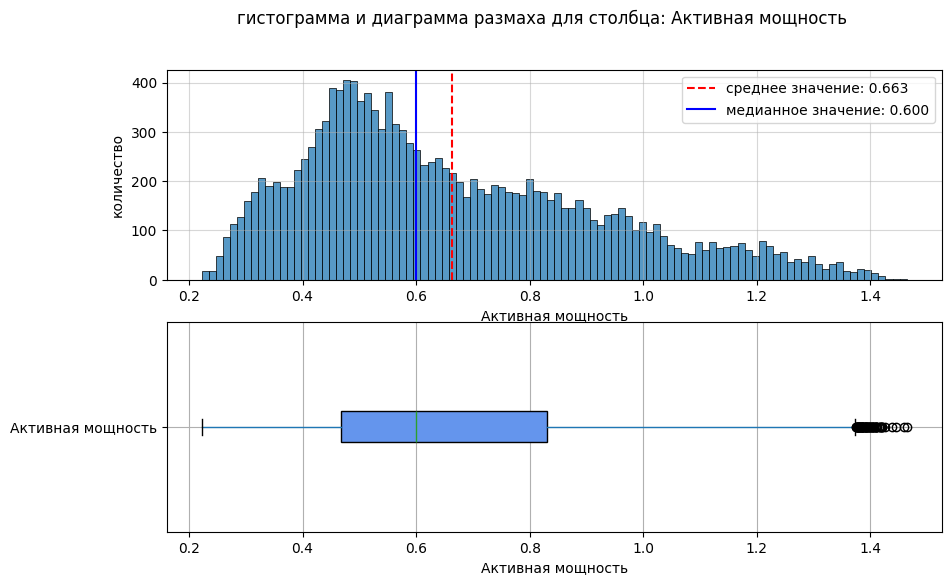

In [33]:
# визуализация распределения признаков
visualization(data_arc, 'Активная мощность', 'Активная мощность', num_col=True)

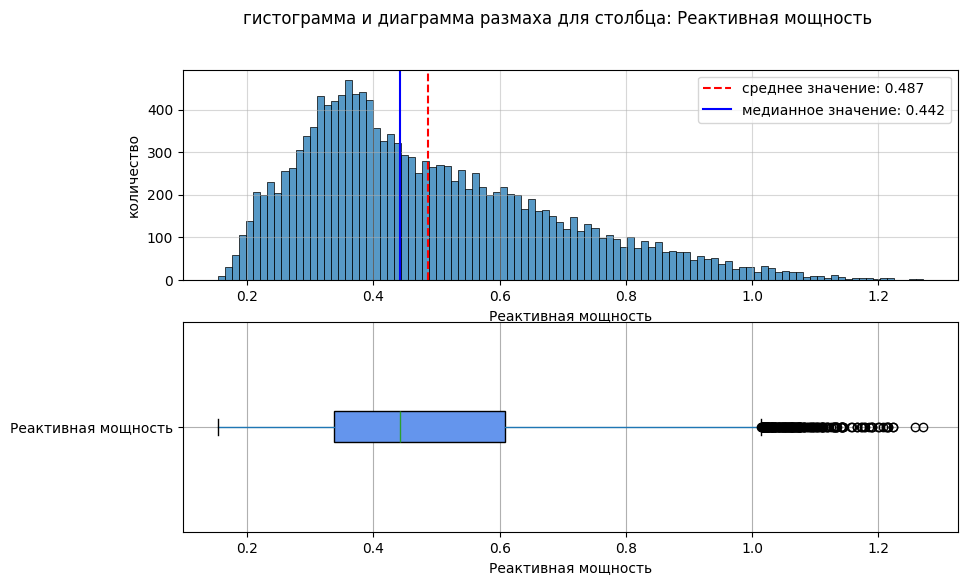

In [34]:
visualization(data_arc, 'Реактивная мощность', 'Реактивная мощность', num_col=True)

\
Создадим и визуализируем распределение значений новых признаков:
- времени нагрева в секундах (`длительность_нагрева`);
- полной мощности (`полная_мощность`);
- коэффициента мощности cos φ (`коэффициент_мощности`)

In [36]:
# создание признака длительность_нагрева
data_arc['длительность_нагрева'] = (data_arc['Конец нагрева дугой'] - 
                                      data_arc['Начало нагрева дугой']).dt.total_seconds()

# создание признака полная_мощность 
data_arc['полная_мощность'] = np.sqrt(data_arc['Активная мощность']**2 + data_arc['Реактивная мощность']**2)

# создание признака коэффициент_мощности 
data_arc['коэффициент_мощности'] = (data_arc['Активная мощность'] / data_arc['полная_мощность'])

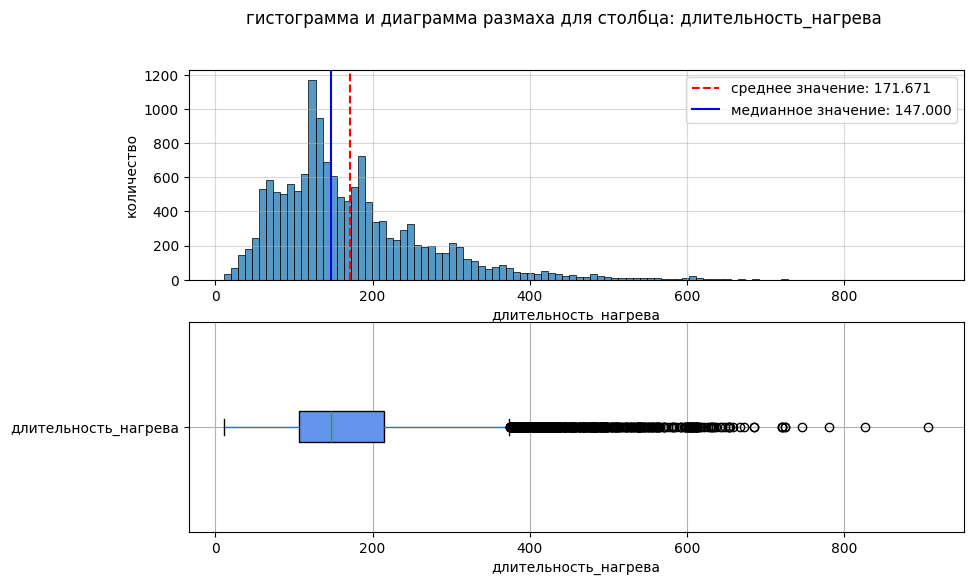

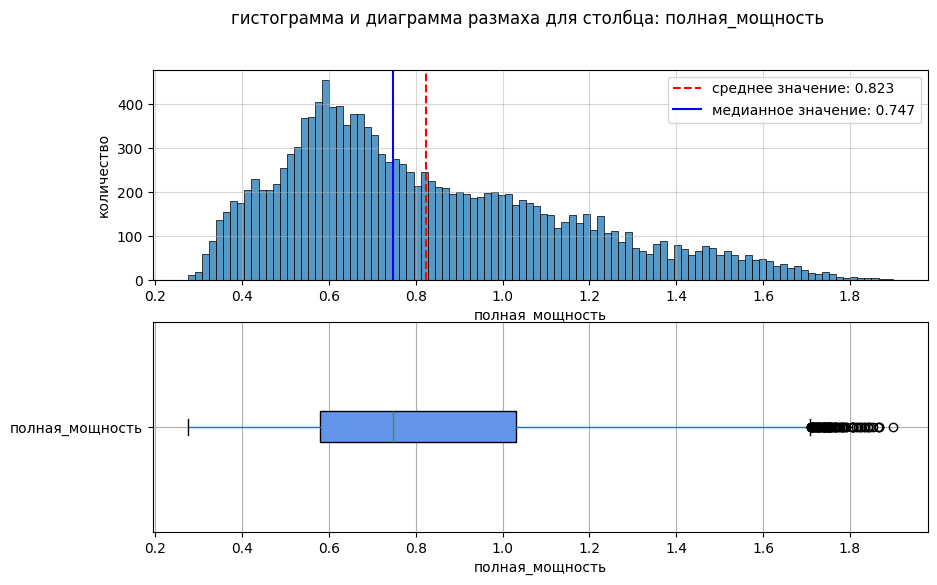

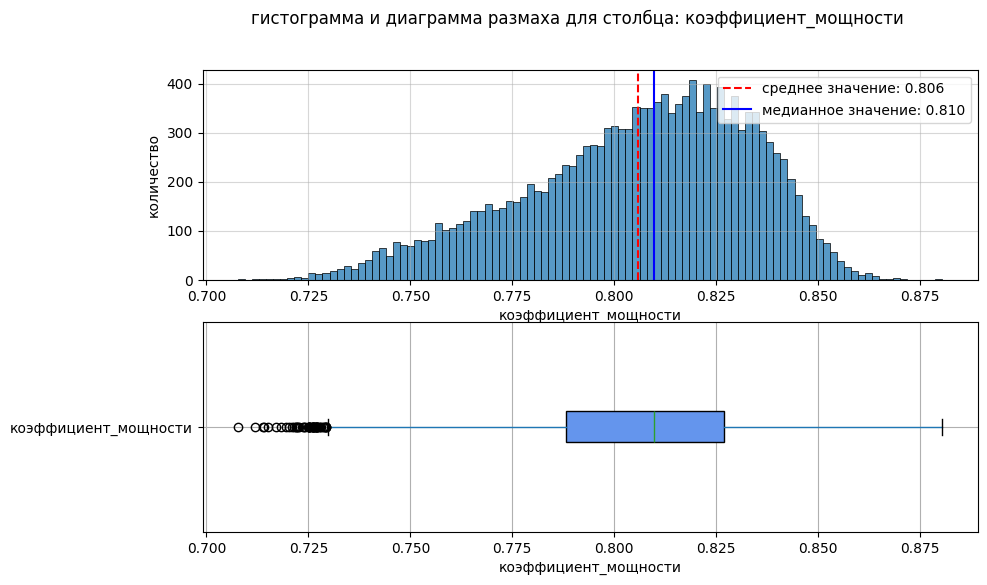

In [37]:
# визуализация новых признаков
data_arc_new_cols = ['длительность_нагрева', 'полная_мощность', 'коэффициент_мощности']

for col in data_arc_new_cols:
    visualization(data_arc, col, col)

\
для корректной агригации данных по партиям создатим признаки:
- активная_энергия;
- реактивная_энергия;
- полная_энергия

На этапе корреляционного анализа объединенных данных удалим лишние признаки

In [38]:
data_arc['активная_энергия'] = data_arc['Активная мощность'] * data_arc['длительность_нагрева']
data_arc['реактивная_энергия'] = data_arc['Реактивная мощность'] * data_arc['длительность_нагрева']
data_arc['полная_энергия'] = data_arc['полная_мощность'] * data_arc['длительность_нагрева']

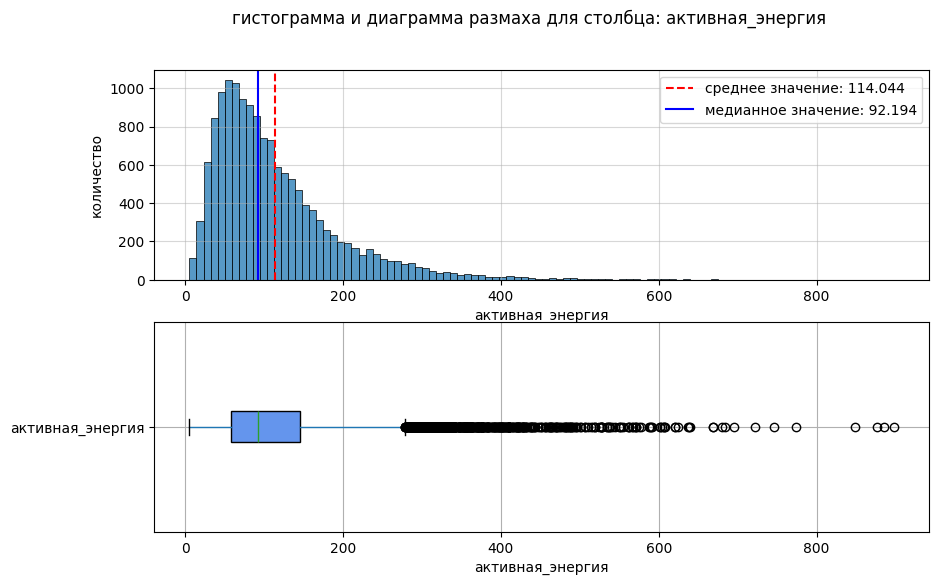

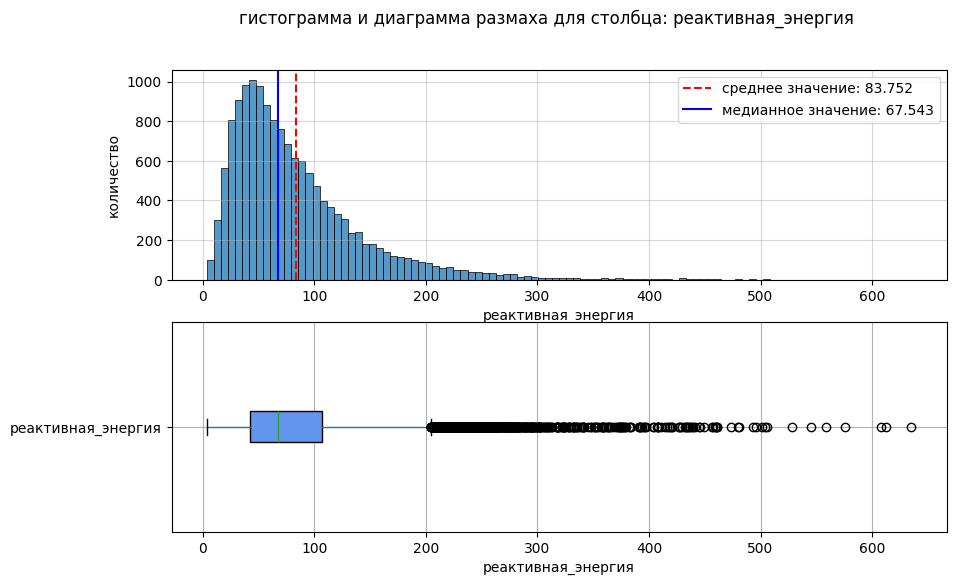

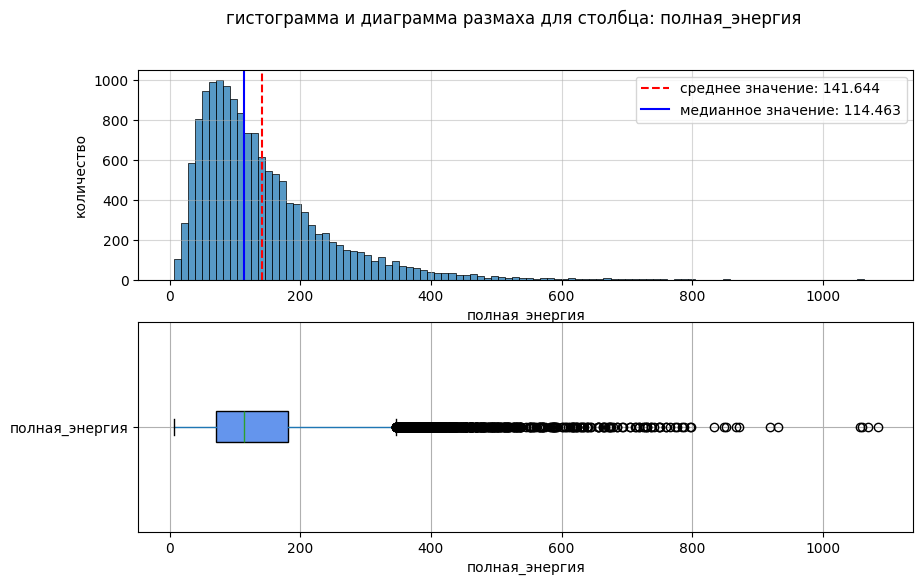

In [39]:
# визуализация новых признаков
data_arc_new_cols = ['активная_энергия', 'реактивная_энергия', 'полная_энергия']

for col in data_arc_new_cols :
    visualization(data_arc, col, col)

\
Проведем агрегацию данных с выделением признаков:
`количество_нагревов` - общее количество нагревов партии;
- `общ_длительность_нагрева` - общая длительность нагрева партии в секундах;
- `активная_мощность_средн` - средневзвешенная активная мощность партии с учетом всех нагревов
- `реактивная_мощность_средн` - средневзвешенная реактивная мощность партии с учетом всех нагревов
- `полная_мощность_средн` - средневзвешенная полная мощность партии с учетом всех нагревов
- ` активная_энергия ` - активная энергия, затраченная на все нагревы
- ` реактивная_энергия ` - реактивная энергия, затраченная на все нагревы
- ` полная_энергия ` - полная энергия, затраченная на все нагревы
- ` коэффициент_мощности ` - средний коэффициент мощности партии.

In [40]:

# агрегация данных по партиям
data_arc_aggregated = data_arc.groupby('key').apply(
    lambda x: pd.Series({
    'количество_нагревов' : x['Активная мощность'].count(),
    'общ_длительность_нагрева' : x['длительность_нагрева'].sum(),
    'активная_мощность_средн' :  (x['Активная мощность'] * x['длительность_нагрева']).sum() / x['длительность_нагрева'].sum(),
    'реактивная_мощность_средн': (x['Реактивная мощность'] * x['длительность_нагрева']).sum() / x['длительность_нагрева'].sum(),
    'полная_мощность_средн': (x['полная_мощность'] * x['длительность_нагрева']).sum() / x['длительность_нагрева'].sum(),
    'активная_энергия' : x['активная_энергия'].sum(),
    'реактивная_энергия' : x['реактивная_энергия'].sum(),
    'полная_энергия' : x['полная_энергия'].sum(),
    'коэффициент_мощности' : x['коэффициент_мощности'].mean()
    })
).reset_index()


In [41]:
# изменение типа данных
data_arc_aggregated['количество_нагревов'] = data_arc_aggregated['количество_нагревов'].astype(int)

In [42]:
# общая информация о полученном датафрейме
display(data_arc_aggregated.head(3))
data_arc_aggregated.info()

,key,количество_нагревов,общ_длительность_нагрева,активная_мощность_средн,реактивная_мощность_средн,полная_мощность_средн,активная_энергия,реактивная_энергия,полная_энергия,коэффициент_мощности
0,1,5,1098.0,0.572511,0.404817,0.701532,628.616930,444.489437,770.282114,0.816686
1,2,4,811.0,0.487400,0.338705,0.594032,395.281800,274.689995,481.760005,0.825276
2,3,5,655.0,0.888206,0.653495,1.103569,581.774624,428.038924,722.837668,0.809724


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214 entries, 0 to 3213
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   key                        3214 non-null   int64  
 1   количество_нагревов        3214 non-null   int64  
 2   общ_длительность_нагрева   3214 non-null   float64
 3   активная_мощность_средн    3214 non-null   float64
 4   реактивная_мощность_средн  3214 non-null   float64
 5   полная_мощность_средн      3214 non-null   float64
 6   активная_энергия           3214 non-null   float64
 7   реактивная_энергия         3214 non-null   float64
 8   полная_энергия             3214 non-null   float64
 9   коэффициент_мощности       3214 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 251.2 KB


### Таблица data_bulk

In [43]:
# статистический анализ
data_bulk.describe()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000,3129.000000
mean,1624.383509,3.160435,1.779163,47.240332,33.830617,2.633749,21.892298,2.441675,0.015660,0.463407,4.684564,4.345478,203.948226,1.041866,152.706616,115.319271
std,933.337642,11.869164,21.217878,74.239954,56.034505,20.918138,55.492582,31.944063,0.875978,6.154398,20.157323,22.699580,151.419639,14.114252,81.091421,84.488698
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,816.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,105.000000,0.000000,104.000000,0.000000
50%,1622.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,0.000000,148.000000,106.000000
75%,2431.000000,0.000000,0.000000,80.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,263.000000,0.000000,202.000000,204.000000
max,3241.000000,185.000000,325.000000,454.000000,281.000000,603.000000,503.000000,772.000000,49.000000,147.000000,159.000000,313.000000,1849.000000,305.000000,636.000000,405.000000


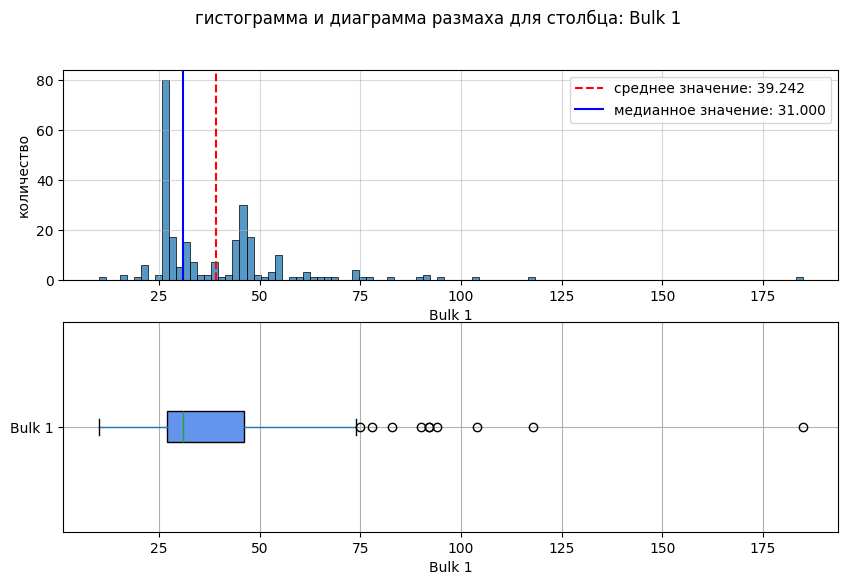

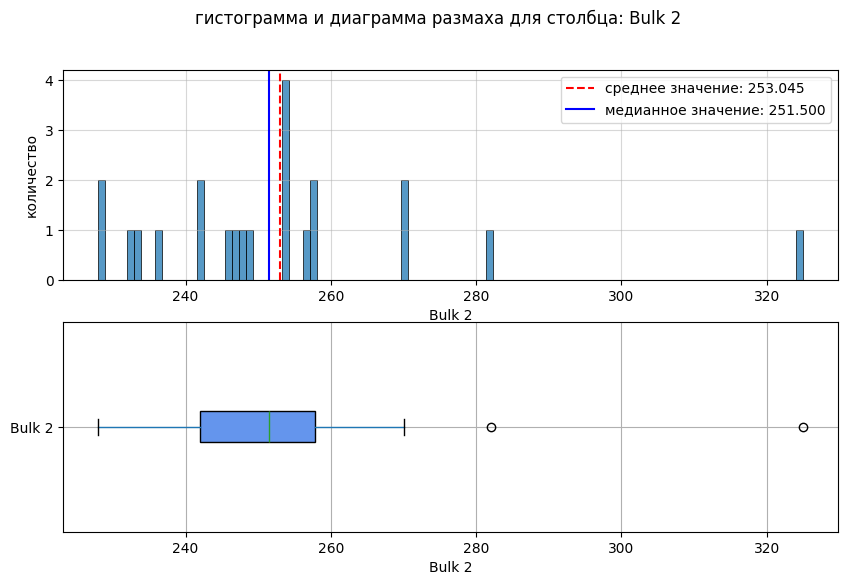

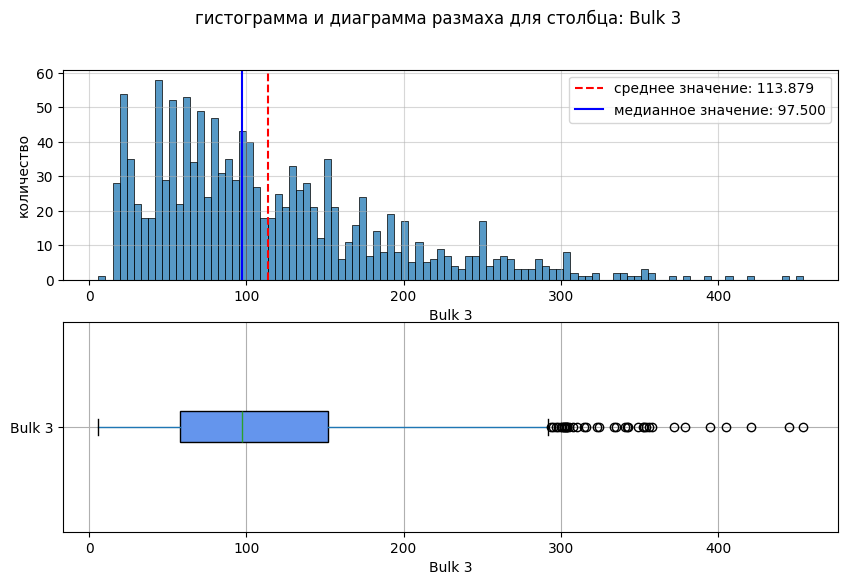

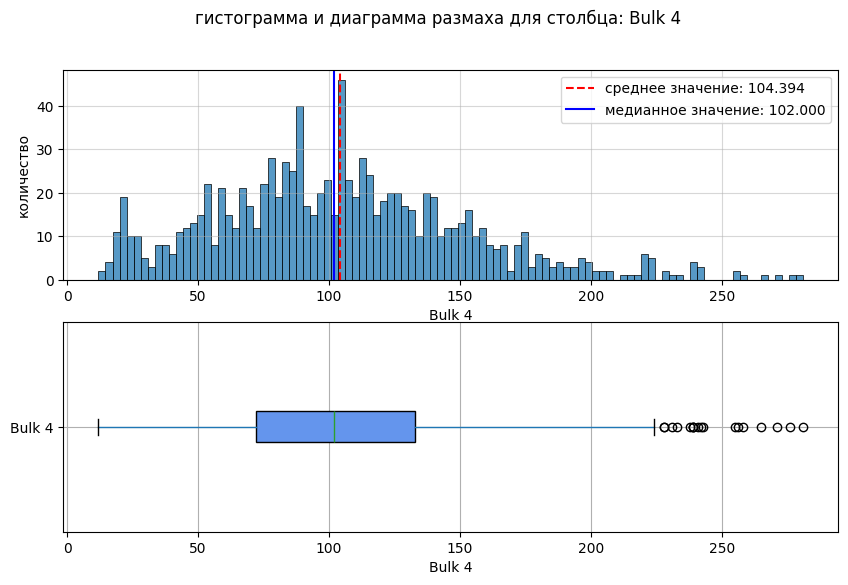

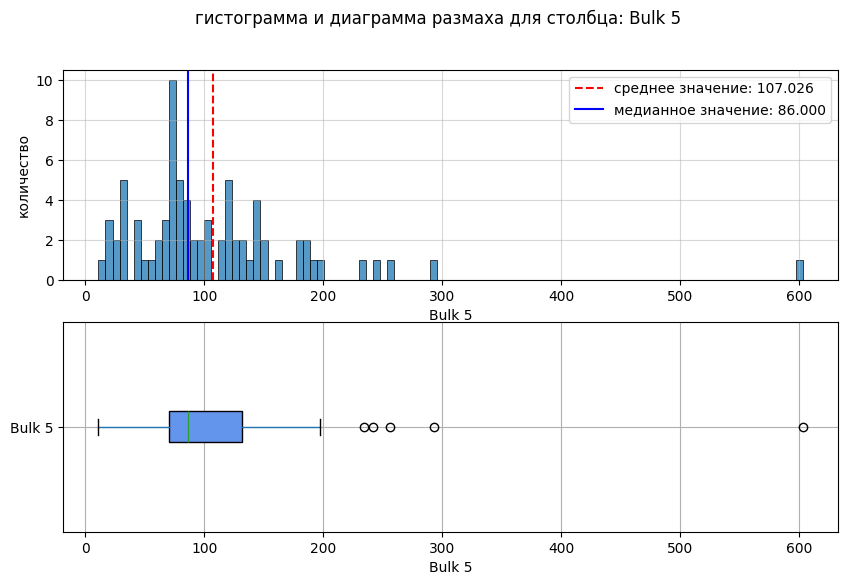

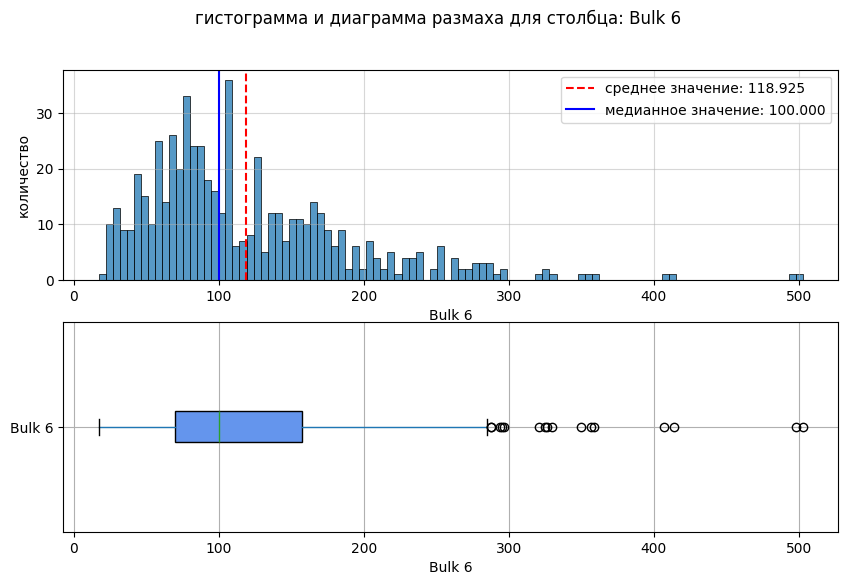

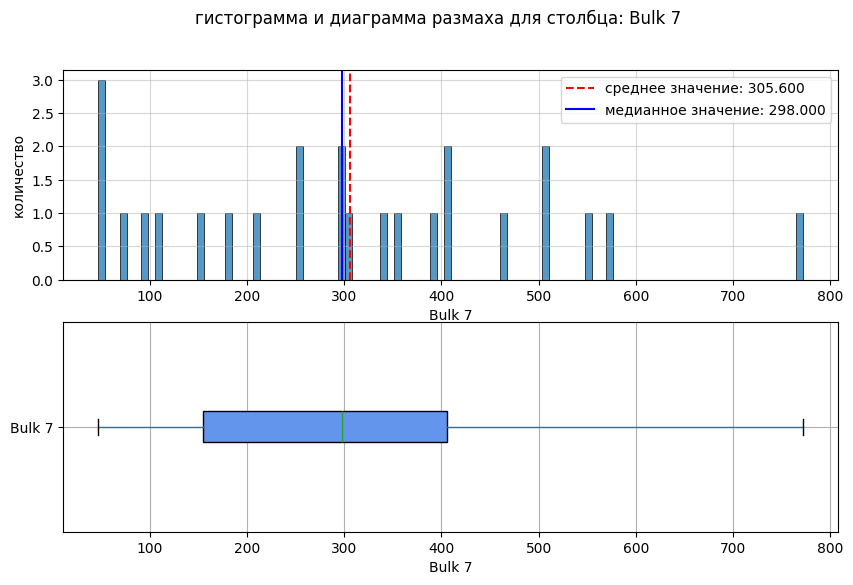

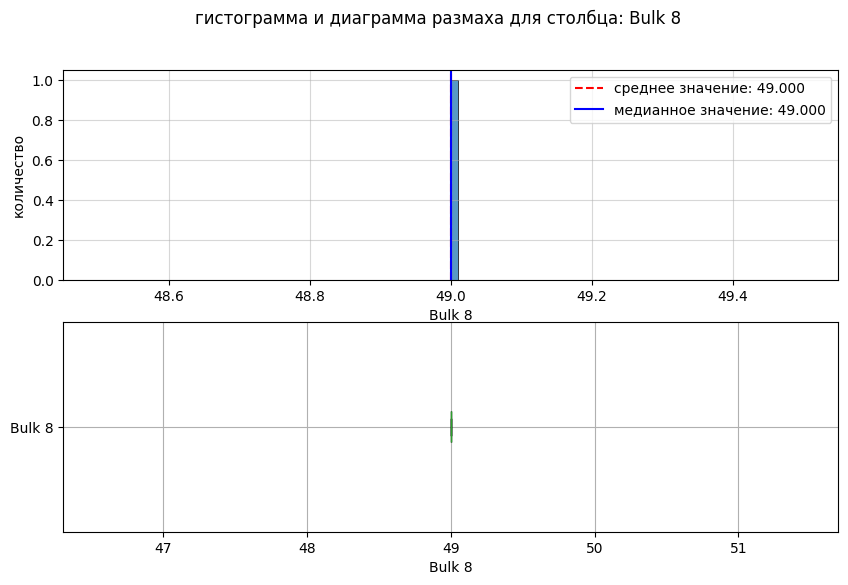

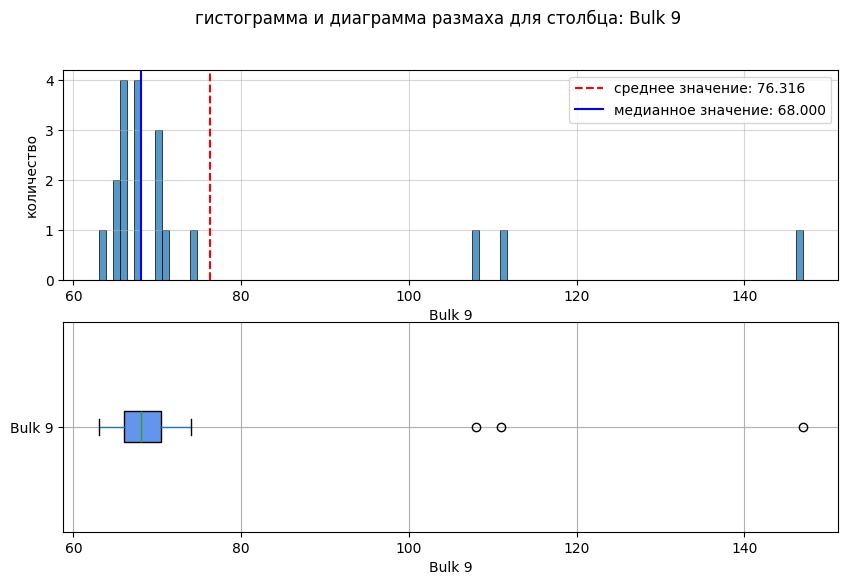

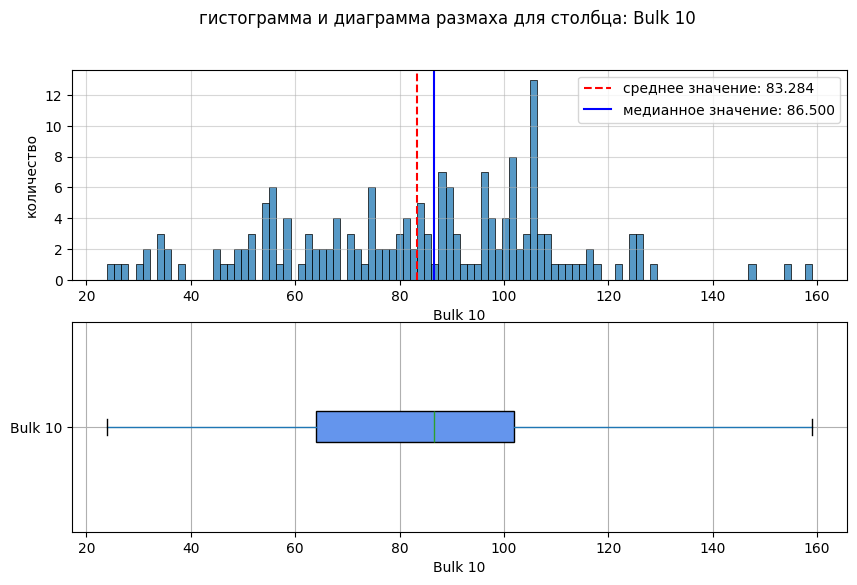

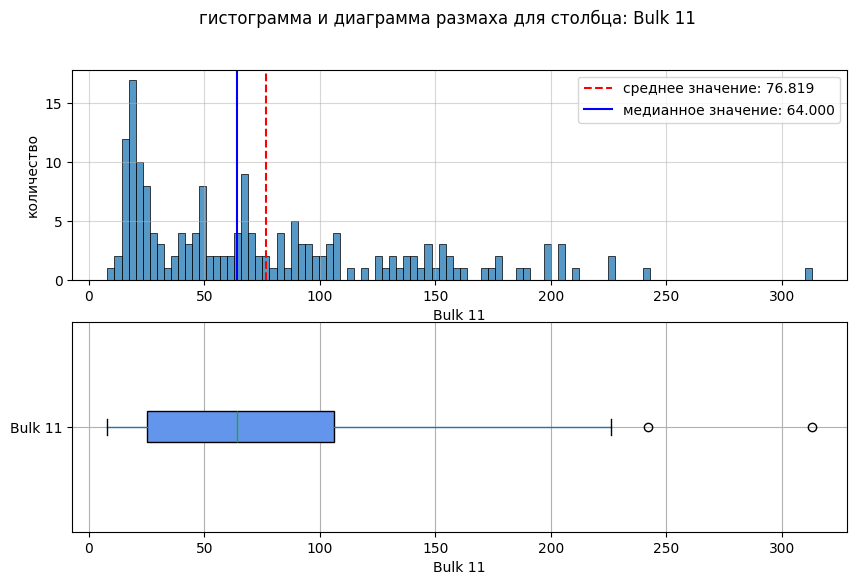

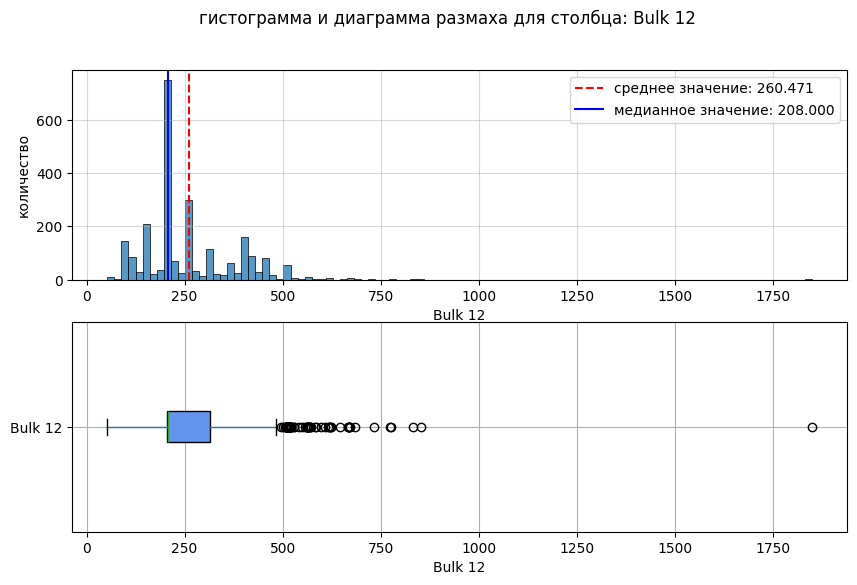

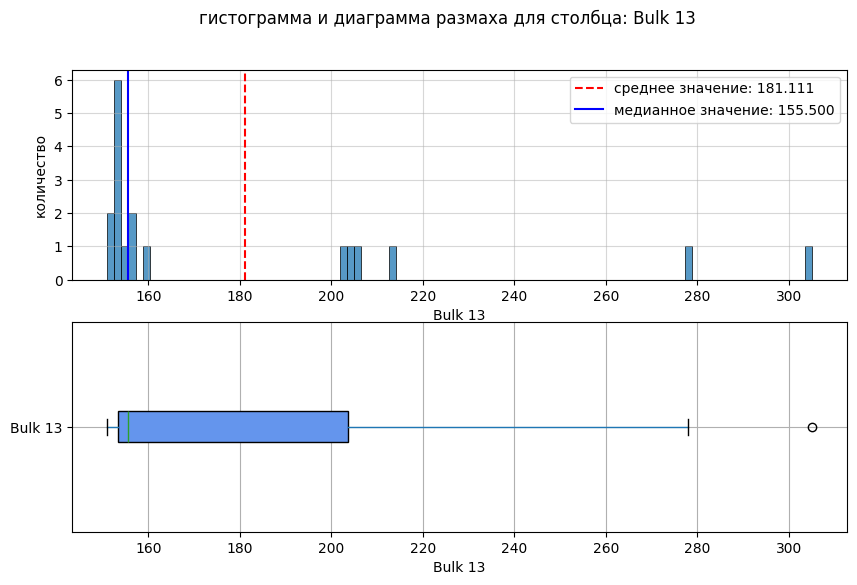

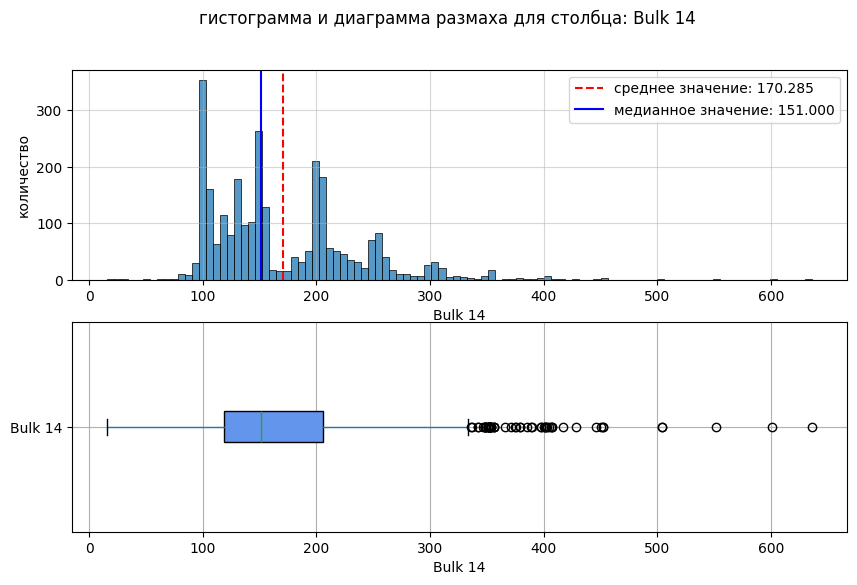

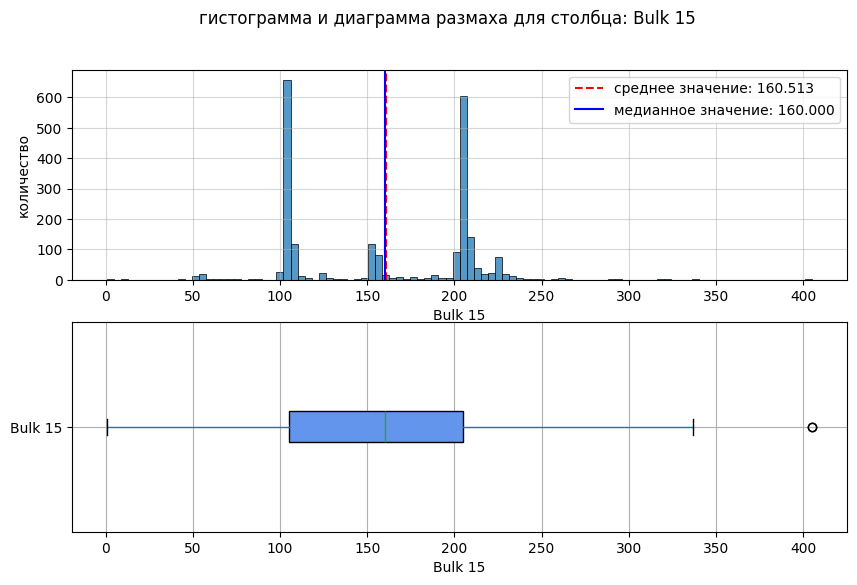

In [44]:
# визуализация распределения значений Bulk 1 - Bulk 15
for col in data_bulk_columns:
    non_zero_data = data_bulk[data_bulk[col] > 0]
    if len(non_zero_data) > 0:
        visualization(non_zero_data, col, col)

\
Проведем обработку аномальных значений таблицы data_bulk для столбцов с количеством пропусков менее 30%

In [45]:
# общая информация о полученном датафрейме
display(data_bulk.head(3))
data_bulk.info()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,0,0,0,43,0,0,0,0,0,0,0,206,0,150,154
1,2,0,0,0,73,0,0,0,0,0,0,0,206,0,149,154
2,3,0,0,0,34,0,0,0,0,0,0,0,205,0,152,153


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   key      3129 non-null   int64
 1   Bulk 1   3129 non-null   int64
 2   Bulk 2   3129 non-null   int64
 3   Bulk 3   3129 non-null   int64
 4   Bulk 4   3129 non-null   int64
 5   Bulk 5   3129 non-null   int64
 6   Bulk 6   3129 non-null   int64
 7   Bulk 7   3129 non-null   int64
 8   Bulk 8   3129 non-null   int64
 9   Bulk 9   3129 non-null   int64
 10  Bulk 10  3129 non-null   int64
 11  Bulk 11  3129 non-null   int64
 12  Bulk 12  3129 non-null   int64
 13  Bulk 13  3129 non-null   int64
 14  Bulk 14  3129 non-null   int64
 15  Bulk 15  3129 non-null   int64
dtypes: int64(16)
memory usage: 391.3 KB


### Таблица data_bulk_time

In [46]:
# статистический анализ
data_bulk_time.describe()

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
count,3129.000000,252,22,1298,1014,77,576,25,1,19,176,177,2450,18,2806,2248
mean,1624.383509,2019-06-29 23:24:44.769841152,2019-07-12 07:57:13.045454592,2019-07-08 13:50:14.630970624,2019-07-03 11:17:28.834319616,2019-07-13 17:18:29.090908928,2019-07-06 13:50:06.345486080,2019-07-27 18:09:05.079999744,2019-07-08 17:14:53,2019-06-23 08:08:47.578947328,2019-07-06 23:55:10.954545408,2019-07-15 07:01:00.615819264,2019-07-05 22:55:11.468571392,2019-07-01 18:32:46.944444416,2019-07-06 07:17:48.372772608,2019-07-06 13:24:51.912366336
min,1.000000,2019-05-03 17:42:46,2019-05-07 15:39:35,2019-05-03 20:40:25,2019-05-03 11:28:48,2019-05-07 15:19:17,2019-05-03 19:09:15,2019-05-07 18:11:01,2019-07-08 17:14:53,2019-05-14 11:57:58,2019-05-06 07:54:02,2019-05-05 23:43:24,2019-05-03 11:24:31,2019-05-05 02:10:21,2019-05-03 11:14:50,2019-05-03 11:10:43
25%,816.000000,2019-05-29 14:48:48.500000,2019-05-28 02:29:31.500000,2019-06-08 03:50:23.500000,2019-05-30 21:36:11.249999872,2019-06-19 23:32:44,2019-06-06 22:46:10.500000,2019-07-20 23:48:47,2019-07-08 17:14:53,2019-05-14 14:31:08,2019-06-02 05:12:00.500000,2019-06-14 20:24:48,2019-06-03 12:48:47.249999872,2019-05-29 10:43:31.249999872,2019-06-04 04:50:42,2019-06-04 11:28:18
50%,1622.000000,2019-06-25 11:09:13,2019-07-27 17:18:38.500000,2019-07-04 09:31:42,2019-06-28 03:44:42.500000,2019-07-25 17:59:41,2019-07-09 03:34:57.500000,2019-07-27 18:07:02,2019-07-08 17:14:53,2019-05-14 16:55:09,2019-07-06 07:05:20,2019-07-24 11:17:22,2019-07-03 01:32:00,2019-07-01 12:59:36.500000,2019-07-03 21:54:13.500000,2019-07-03 16:43:28.500000
75%,2431.000000,2019-07-31 05:58:18.249999872,2019-08-13 02:20:08,2019-08-11 01:00:36.750000128,2019-08-04 04:15:46.500000,2019-08-13 04:23:23,2019-08-07 18:55:01.249999872,2019-08-13 04:19:43,2019-07-08 17:14:53,2019-08-16 05:43:31,2019-08-04 02:23:35.750000128,2019-08-11 05:21:01,2019-08-08 14:55:05.249999872,2019-08-04 23:32:00.249999872,2019-08-09 04:22:40.500000,2019-08-09 09:18:31.750000128
max,3241.000000,2019-09-05 09:11:32,2019-08-13 11:47:39,2019-09-06 12:26:52,2019-09-05 03:35:21,2019-09-02 18:16:52,2019-09-06 16:24:28,2019-09-05 19:07:49,2019-07-08 17:14:53,2019-08-16 09:11:56,2019-09-04 10:03:22,2019-09-06 05:03:14,2019-09-06 15:01:44,2019-09-01 01:53:02,2019-09-06 17:26:33,2019-09-06 17:23:15
std,933.337642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


\
Проверим временные диапазоны каждого признака и и соотнесем с временным диапазоном таблицы data_arc\
А также вузуализируем распределение времени подачи материалов по партиям 

In [47]:
# временной диапазон для data_arc
data_arc_min_time = data_arc['Начало нагрева дугой'].min()
data_arc_max_time = data_arc['Конец нагрева дугой'].max()

# признаки с датами таблицы data_bulk_time
bulk_time_cols = [col for col in data_bulk_time.columns if col != 'key']

data_bulk_time_stats = []

for col in bulk_time_cols:
    # удаление пропусков
    non_null_times = data_bulk_time[col].dropna()
    
    if len(non_null_times) > 0:
        min_time = non_null_times.min()
        max_time = non_null_times.max()
        total_count = len(non_null_times)
        
        # количество значений, попадающих (не попадающих) в диапазон data_arc
        in_data_arc_range = ((non_null_times >= data_arc_min_time) & 
                        (non_null_times <= data_arc_max_time)).sum()
        out_of_range = total_count - in_data_arc_range
        
        # количество значений раньше начала нагрева 
        # и позже конца нагрева
        before_start = (non_null_times < data_arc_min_time).sum()
        after_end = (non_null_times > data_arc_max_time).sum()
        
        data_bulk_time_stats.append({
            'признак': col,
            'количество': total_count,
            'min время': min_time,
            'max время': max_time,
            'в диапазоне data_arc': in_data_arc_range,
            '% в диапазоне': (in_data_arc_range / total_count * 100).round(2),
            'до начала нагрева': before_start,
            'после окончания': after_end,
            'вне диапазона': out_of_range
        })
bulk_time_stats_df = pd.DataFrame(data_bulk_time_stats)

In [48]:
bulk_time_stats_df

,признак,количество,min время,max время,в диапазоне data_arc,% в диапазоне,до начала нагрева,после окончания,вне диапазона
0,Bulk 1,252,2019-05-03 17:42:46,2019-09-05 09:11:32,252,100.00,0,0,0
1,Bulk 2,22,2019-05-07 15:39:35,2019-08-13 11:47:39,22,100.00,0,0,0
2,Bulk 3,1298,2019-05-03 20:40:25,2019-09-06 12:26:52,1298,100.00,0,0,0
3,Bulk 4,1014,2019-05-03 11:28:48,2019-09-05 03:35:21,1014,100.00,0,0,0
4,Bulk 5,77,2019-05-07 15:19:17,2019-09-02 18:16:52,77,100.00,0,0,0
5,Bulk 6,576,2019-05-03 19:09:15,2019-09-06 16:24:28,576,100.00,0,0,0
6,Bulk 7,25,2019-05-07 18:11:01,2019-09-05 19:07:49,25,100.00,0,0,0
7,Bulk 8,1,2019-07-08 17:14:53,2019-07-08 17:14:53,1,100.00,0,0,0
8,Bulk 9,19,2019-05-14 11:57:58,2019-08-16 09:11:56,19,100.00,0,0,0
9,Bulk 10,176,2019-05-06 07:54:02,2019-09-04 10:03:22,176,100.00,0,0,0


In [49]:
# строка со временем вне диапазона
max_bulk14_time = data_bulk_time['Bulk 14'].max()

print('\nмаксимальное время окончания нагрева из data_arc:',
      data_arc_max_time, '\n')

data_bulk_time[data_bulk_time['Bulk 14'] == max_bulk14_time]


максимальное время окончания нагрева из data_arc: 2019-09-06 17:26:15 



,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
3128,3241,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,NaT,2019-09-06 17:26:33,2019-09-06 17:23:15


In [50]:
# диапазон времени подачи материалов по партиям в секундах

bulk_time_long = data_bulk_time.melt(
    id_vars=['key'],
    var_name='bulk_material',
    value_name='event_time'
)

# удаление пропусков
bulk_time_long = bulk_time_long.dropna(subset=['event_time'])

# сортировка по партиям и времени
bulk_time_long = bulk_time_long.sort_values(['key', 'event_time'])

# разница между событиями внутри партии
bulk_time_long['time_diff'] = bulk_time_long.groupby('key')['event_time'].diff()


# разница между первой и последней подачей матариалов по партиям
durations_bulk = bulk_time_long.groupby('key')['event_time'].agg(
    first_event='min',
    last_event='max'
)
durations_bulk['bulk_total_duration'] = (durations_bulk['last_event'] - durations_bulk['first_event']).dt.total_seconds()

In [51]:
# добавление столбца total_duration в таблицу data_bulk_time
data_bulk_time = data_bulk_time.merge(durations_bulk['bulk_total_duration'], on='key', how='left')

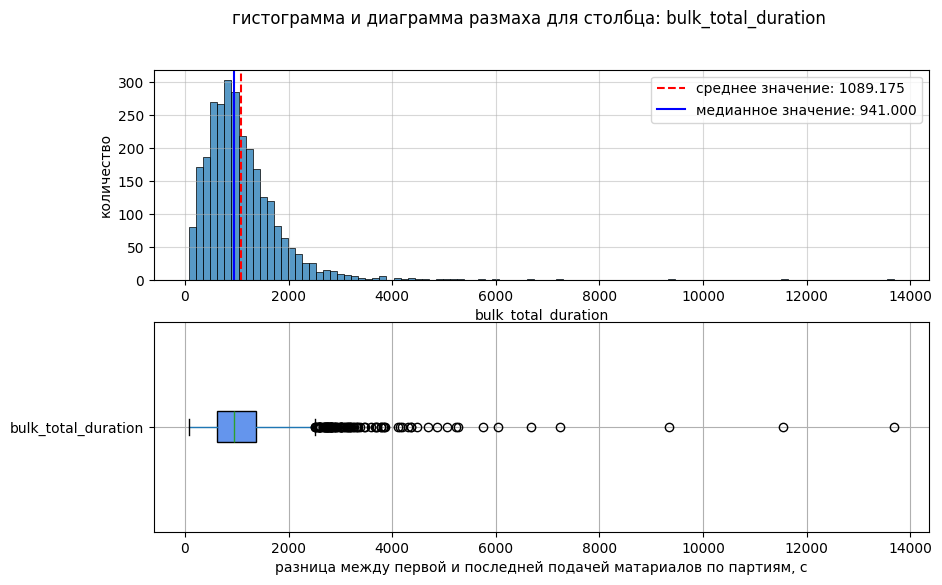

In [52]:
# построим распределение значений диапазона подачи материалов
# для строк с total_duration больше 0
filtered_data_bulk = data_bulk_time[data_bulk_time['bulk_total_duration'] > 0]


visualization(filtered_data_bulk, 'bulk_total_duration', 
              'разница между первой и последней подачей матариалов по партиям, c')

\
Проведем агрегацию данных (создадим датафрейм `data_bulk_aggregated`) с образованием признаков:
- `общ_объем_сыпучих_материалов` - общий объем сыпучих материалов по партиям;
- `количество_типов_материалов` - количество типов материалов, добавленных в партию;
- `общ_время_подачи_сыпучих_материалов` - диапазон времени между первой и последней подачей материалов по партиям в секундах (при использовании только одного типа материалов или при одновременном добавлении нескольких примем время подачи равное 1 минуте);
- `avg_объем_сыпучих_материалов` - средний объем подачи сыпучих материалов в минуту;

In [53]:
# агрегация данных по партиям
data_bulk_aggregated = pd.DataFrame(
    {'key' : data_bulk['key']})

data_bulk_aggregated['общ_объем_сыпучих_материалов'] = data_bulk[data_bulk_columns].sum(axis=1)
data_bulk_aggregated['количество_типов_сыпучих_материалов'] = (data_bulk[data_bulk_columns] > 0).sum(axis=1)

# добавление столбца общ_время_подачи_сыпучих_материалов
data_bulk_aggregated = data_bulk_aggregated.merge(
    data_bulk_time[['key', 'bulk_total_duration']],
    on='key',
    how='left'
)
data_bulk_aggregated = data_bulk_aggregated.rename(
    columns={'bulk_total_duration': 'общ_время_подачи_сыпучих_материалов'}
)

# если использован только один тип материалов или при одновременном добавлении нескольких 
# примем медианное время подачи для партии
median_time = data_bulk_aggregated[data_bulk_aggregated['общ_время_подачи_сыпучих_материалов'] > 0]\
    ['общ_время_подачи_сыпучих_материалов'].median()

data_bulk_aggregated['общ_время_подачи_сыпучих_материалов'] = \
   data_bulk_aggregated['общ_время_подачи_сыпучих_материалов'].replace(0, median_time)


# добавление столбца avg_объем_сыпучих_материалов
data_bulk_aggregated['avg_объем_сыпучих_материалов'] = data_bulk_aggregated['общ_объем_сыпучих_материалов'] \
    / (data_bulk_aggregated['общ_время_подачи_сыпучих_материалов'] / 60)

data_bulk_aggregated['средний_объем_сыпучих_материалов'] =\
    data_bulk_aggregated['общ_объем_сыпучих_материалов'] / (data_bulk_aggregated['количество_типов_сыпучих_материалов'])

In [54]:
# заполнение пропусков
bulk_aggregated_columns = [col for col in data_bulk_aggregated if col != 'key']

data_bulk_aggregated[bulk_aggregated_columns] = data_bulk_aggregated[bulk_aggregated_columns].fillna(0)

In [55]:
# общая информация о полученном датафрейме
display(data_bulk_aggregated.head(3))
data_bulk_aggregated.info()

,key,общ_объем_сыпучих_материалов,количество_типов_сыпучих_материалов,общ_время_подачи_сыпучих_материалов,avg_объем_сыпучих_материалов,средний_объем_сыпучих_материалов
0,1,553,4,1085.0,30.580645,138.25
1,2,582,4,1000.0,34.920000,145.50
2,3,544,4,983.0,33.204476,136.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3129 entries, 0 to 3128
Data columns (total 6 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   key                                  3129 non-null   int64  
 1   общ_объем_сыпучих_материалов         3129 non-null   int64  
 2   количество_типов_сыпучих_материалов  3129 non-null   int64  
 3   общ_время_подачи_сыпучих_материалов  3129 non-null   float64
 4   avg_объем_сыпучих_материалов         3129 non-null   float64
 5   средний_объем_сыпучих_материалов     3129 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 146.8 KB


### Таблица data_gas

In [56]:
# статистический анализ
data_gas.describe()

,key,Газ 1
count,3239.000000,3239.000000
mean,1621.861377,11.002062
std,935.386334,6.220327
min,1.000000,0.008399
25%,812.500000,7.043089
50%,1622.000000,9.836267
75%,2431.500000,13.769915
max,3241.000000,77.995040


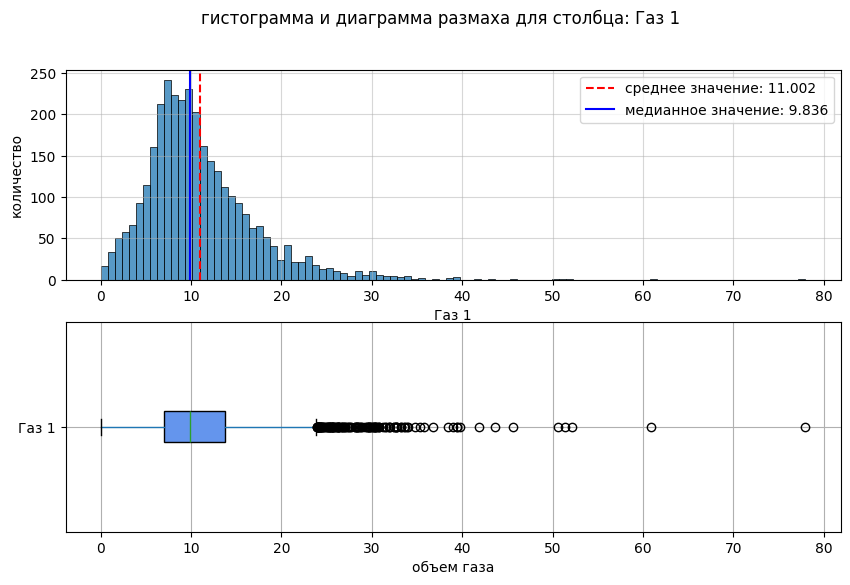

In [57]:
visualization(data_gas, 'Газ 1', 'объем газа')

### Таблица data_temp

In [58]:
# статистический анализ
data_temp.describe()

,key,Время замера,Температура
count,18092.000000,18092,18092.000000
mean,1616.460977,2019-07-05 13:36:58.791620608,1289.406865
min,1.000000,2019-05-03 11:02:04,0.000000
25%,807.750000,2019-06-04 00:35:01.249999872,1567.000000
50%,1618.000000,2019-07-03 02:11:48,1586.000000
75%,2429.000000,2019-08-07 23:10:05.249999872,1597.000000
max,3241.000000,2019-09-06 17:30:05,1705.000000
std,934.641385,NaN,623.600333


\
Проверим есть ли партии у которых последняя измеренная температура не заполнена (равна 0), при наличии удалим данные партии (т.к. заполнение данных значений повлияет на качество модели)

In [59]:
# время последнего замера температуры партии
last_time_idx = data_temp.groupby('key')['Время замера'].idxmax()

# температура последнего замера
last_temps = data_temp.loc[last_time_idx, ['key', 'Температура']]

# список партий с последней измеренной температурой = 0
keys_to_remove = last_temps[last_temps['Температура'] == 0]['key'].unique()

# удаление партий из списка keys_to_remove
data_temp_filtered = data_temp[~data_temp['key'].isin(keys_to_remove)]

print('удалено', len(keys_to_remove),
      'партий с нулевой последней измеренной температурой')

удалено 739 партий с нулевой последней измеренной температурой


In [60]:
# количество партий с хотя бы одним нулевым замером
len(data_temp_filtered[data_temp_filtered['Температура'] == 0]['key'].unique())

0

In [61]:
# удалим строки со значениями температуры NaN
data_temp_filtered = data_temp_filtered.dropna(subset=['Температура'])

In [62]:
# проверим есть ли партии без значений температуры
zero_keys = data_temp_filtered.groupby('key')['Температура'].apply(lambda x: (x == 0).all())
keys_with_all_zero = zero_keys[zero_keys].index.tolist()
print(f'количество партий без значений температуры: {len(keys_with_all_zero)}')

количество партий без значений температуры: 0


In [63]:
# удалим партии со значением температуры менее 1500 градусов
keys_to_remove = data_temp_filtered[data_temp_filtered['Температура'] < 1500]['key'].unique()

data_temp_filtered = data_temp_filtered[~data_temp_filtered['key'].isin(keys_to_remove)]

print('удалено', len(keys_to_remove),
      'партии со значениями температур менее 1500')

удалено 4 партии со значениями температур менее 1500


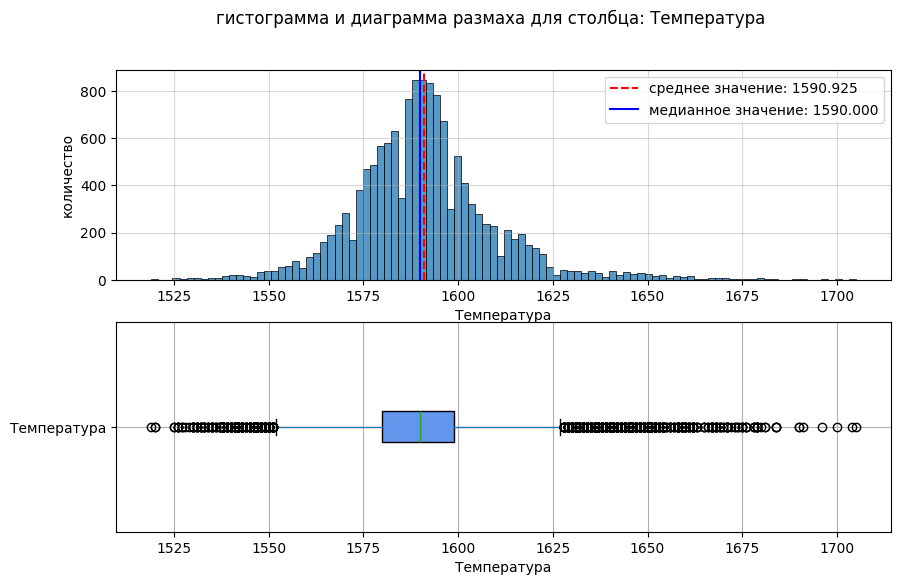

In [64]:
# визуализация распределения значений температуры
visualization(data_temp_filtered, 'Температура', 'Температура')

\
Проведем агрегацию данных по партиям с выелением признаков (при агрегации выберем партии, у которых не менее двух замеров температуры):
- `начальная_температура` - первая измеренная температура;
- **`температура` - последняя измеренная температура (целевая переменная)**;
- `количество_замеров_температуры` - количество измерений температуры партии;
- `время_между_замерами` - время между первым и последним измерением температуры в секунах.

In [65]:
# список партий с количеством измерений темературы не менее 2
temp_keys = data_temp['key'].value_counts().loc[lambda x: x >= 2].index

# отфильтрованные данные
data_temp_filtered = data_temp_filtered[data_temp_filtered['key'].isin(temp_keys)]

# агрегация данных по партиям с выделением целевой переменной
# и начальной температуры партии
data_temp_aggregated = data_temp_filtered.sort_values('Время замера').groupby('key').apply(
    lambda x: pd.Series({
        'начальная_температура' : x['Температура'].iloc[0],
        'температура' : x['Температура'].iloc[-1].astype(int),
        'количество_замеров_температуры' : x['Температура'].count(),
        'время_между_замерами' : (x['Время замера'].iloc[-1] - x['Время замера'].iloc[0])\
            .total_seconds() if len(x['Температура']) > 1 else 0
    })
).reset_index()

In [66]:
cols_to_change = ['начальная_температура', 'температура', 'количество_замеров_температуры', 'время_между_замерами']

data_temp_aggregated[cols_to_change] = data_temp_aggregated[cols_to_change].astype(int)

In [67]:
# общая информация о полученном датафрейме
display(data_temp_aggregated.head(3))
data_temp_aggregated.info()

,key,начальная_температура,температура,количество_замеров_температуры,время_между_замерами
0,1,1571,1613,6,1714
1,2,1581,1602,5,1265
2,3,1596,1599,6,1753


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 5 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   key                             2471 non-null   int64
 1   начальная_температура           2471 non-null   int64
 2   температура                     2471 non-null   int64
 3   количество_замеров_температуры  2471 non-null   int64
 4   время_между_замерами            2471 non-null   int64
dtypes: int64(5)
memory usage: 96.7 KB


### Таблица data_wire

In [68]:
# статистический анализ
data_wire.describe()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000,3081.000000
mean,1623.426485,100.044411,17.712733,3.874524,0.261019,0.004911,1.137695,0.035842,0.330697,0.321492
std,932.996726,42.841120,33.517734,30.310417,4.293865,0.272615,8.958111,0.774190,4.392677,3.806904
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,823.000000,70.281120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1619.000000,100.114563,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2434.000000,125.798405,23.162880,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3241.000000,330.314424,282.780152,385.008668,113.231044,15.132000,180.454575,32.847674,102.762401,90.053604


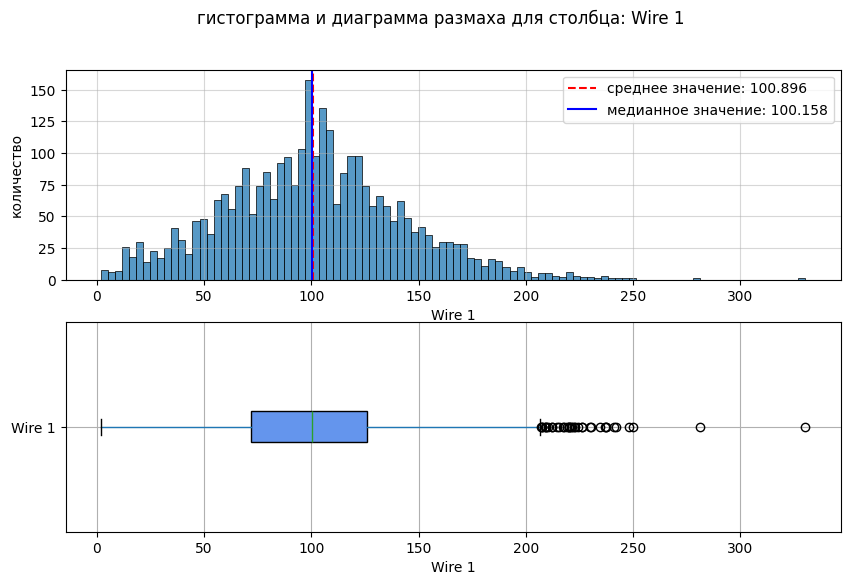

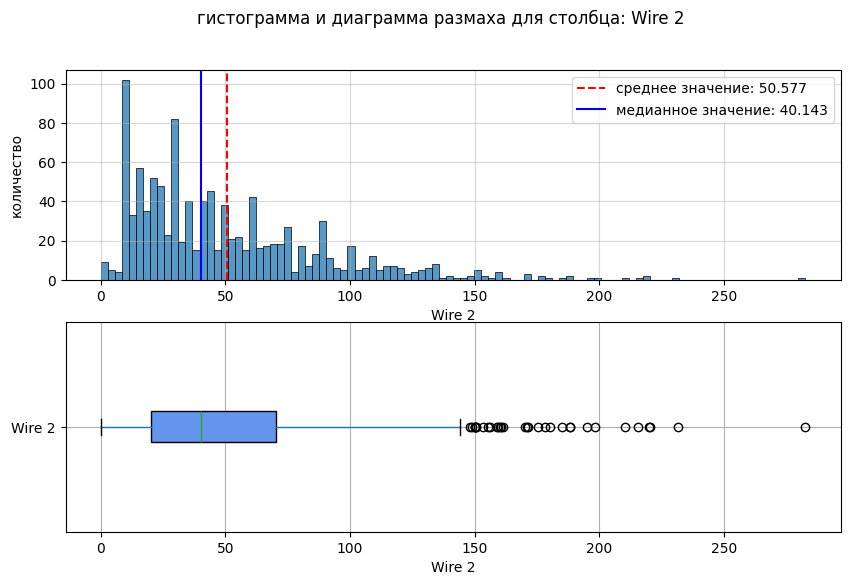

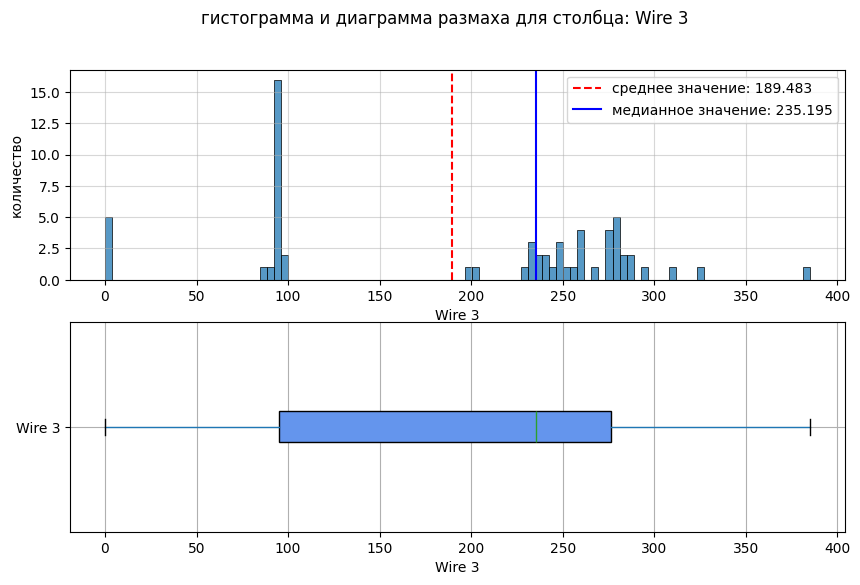

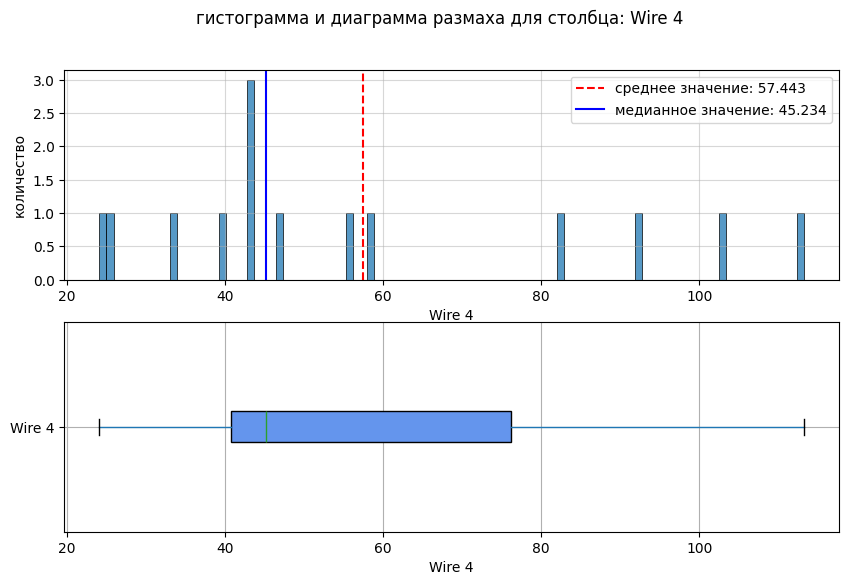

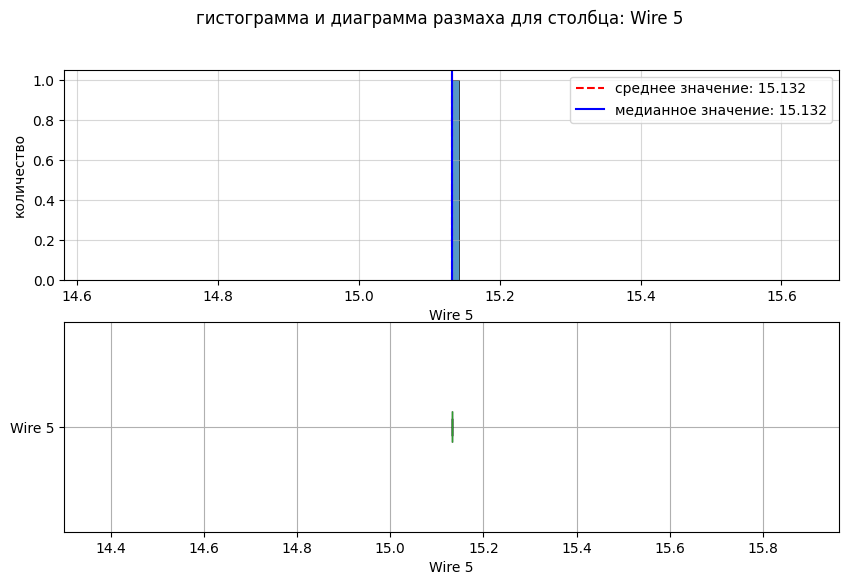

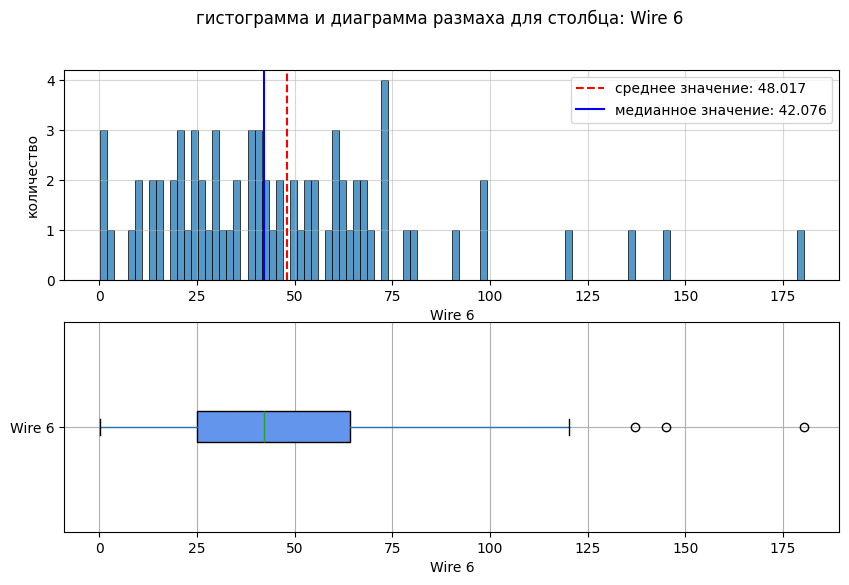

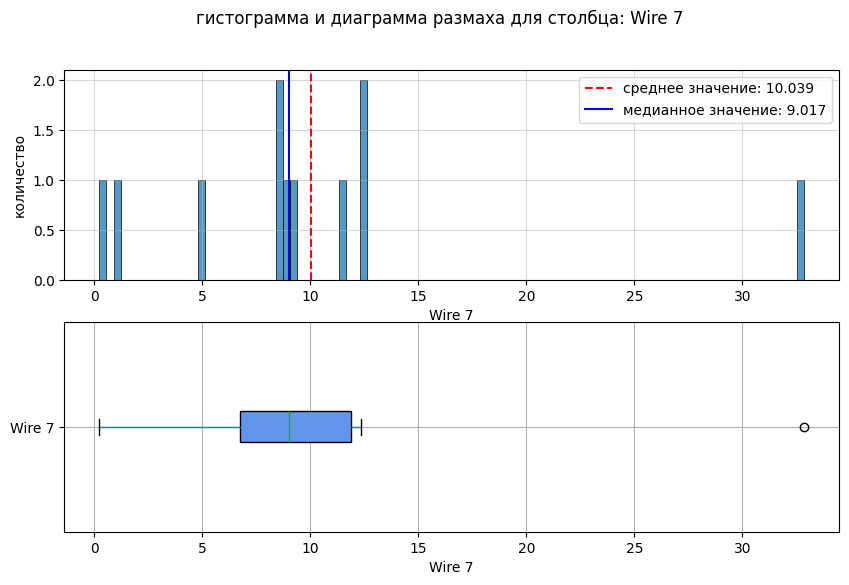

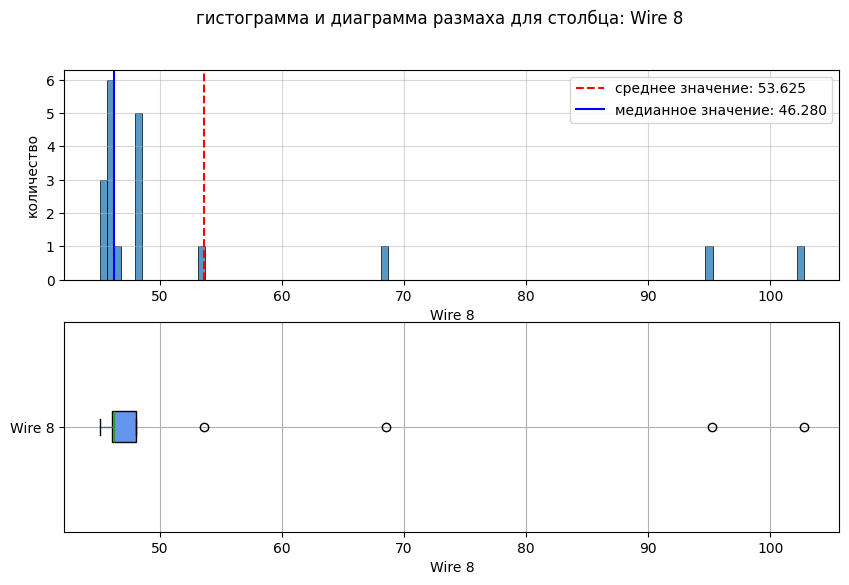

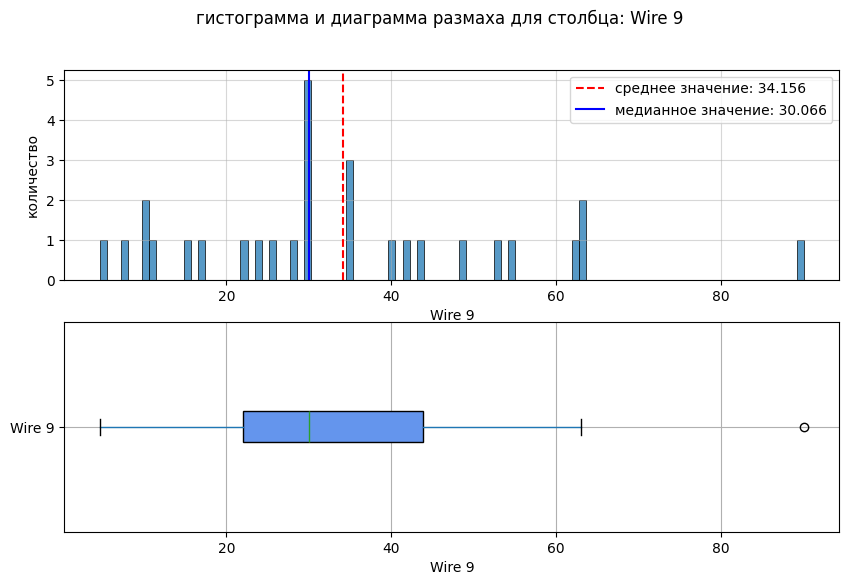

In [69]:
# визуализация распределения значений Wire 1 - Wire 9
for col in data_wire_columns:
    non_zero_data = data_wire[data_wire[col] > 0]
    if len(non_zero_data) > 0:
        visualization(non_zero_data, col, col)

\
Проведем обработку аномальных значений таблицы data_wire для столбца Wire 1 (т.к. в нем менее 1% пропусков)

### Таблица data_wire_time

In [70]:
# статистический анализ
data_wire_time.describe()

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
count,3081.000000,3055,1079,63,14,1,73,11,19,29
mean,1623.426485,2019-07-05 23:22:34.279541760,2019-07-07 01:07:08.735866624,2019-07-10 15:09:58.650793472,2019-07-11 13:44:37,2019-08-13 06:14:30,2019-07-07 11:51:15.095890432,2019-08-07 01:16:08.090909184,2019-06-23 07:47:49.052631552,2019-07-01 11:56:04.793103616
min,1.000000,2019-05-03 11:06:19,2019-05-03 13:15:34,2019-05-04 04:34:27,2019-05-07 15:19:17,2019-08-13 06:14:30,2019-05-07 14:46:05,2019-07-27 05:49:05,2019-05-14 11:29:24,2019-05-04 17:21:27
25%,823.000000,2019-06-04 19:30:11.500000,2019-06-05 14:50:26.500000,2019-06-11 14:17:38.500000,2019-07-20 17:58:53.750000128,2019-08-13 06:14:30,2019-05-08 21:47:30,2019-07-27 16:27:27,2019-05-14 14:20:07.500000,2019-06-09 19:36:17
50%,1619.000000,2019-07-03 06:36:23,2019-07-04 23:13:39,2019-07-21 10:04:47,2019-07-27 05:45:26.500000,2019-08-13 06:14:30,2019-07-28 05:00:32,2019-08-12 21:48:11,2019-05-14 16:55:09,2019-06-11 10:10:21
75%,2434.000000,2019-08-08 08:56:06.500000,2019-08-08 23:15:17,2019-08-12 22:54:46,2019-07-27 16:20:04.750000128,2019-08-13 06:14:30,2019-08-13 13:33:02,2019-08-13 02:02:55.500000,2019-08-16 05:06:53.500000,2019-08-09 06:49:04
max,3241.000000,2019-09-06 17:10:06,2019-09-06 07:35:40,2019-09-02 07:14:44,2019-08-13 03:16:45,2019-08-13 06:14:30,2019-08-18 19:10:56,2019-08-13 10:25:22,2019-08-16 08:56:23,2019-09-03 12:55:23
std,932.996726,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


\
Проверим временные диапазоны каждого признака и и соотнесем с временным диапазоном таблицы data_arc
А также вузуализируем распределение времени подачи материалов по партиям

In [71]:
# признаки с датами таблицы data_bulk_time
wire_time_cols = [col for col in data_wire_time.columns if col != 'key']

data_wire_time_stats = []

for col in wire_time_cols:
    # удаление пропусков
    non_null_times = data_wire_time[col].dropna()

    if len(non_null_times) > 0:
        min_time = non_null_times.min()
        max_time = non_null_times.max()
        total_count = len(non_null_times)

        # количество значений, попадающих (не попадающих) в диапазон data_arc
        in_data_arc_range = (
            (non_null_times >= data_arc_min_time)
            & (non_null_times <= data_arc_max_time)
        ).sum()
        out_of_range = total_count - in_data_arc_range

        # количество значений раньше начала нагрева 
        # и позже конца нагрева
        before_start = (non_null_times < data_arc_min_time).sum()
        after_end = (non_null_times > data_arc_max_time).sum()

        data_wire_time_stats.append({
            'признак': col,
            'количество': total_count,
            'min время': min_time,
            'max время': max_time,
            'в диапазоне data_arc': in_data_arc_range,
            '% в диапазоне': (in_data_arc_range / total_count * 100).round(2),
            'до начала нагрева': before_start,
            'после окончания': after_end,
            'вне диапазона': out_of_range
        })

wire_time_stats_df = pd.DataFrame(data_wire_time_stats)

In [72]:
wire_time_stats_df

,признак,количество,min время,max время,в диапазоне data_arc,% в диапазоне,до начала нагрева,после окончания,вне диапазона
0,Wire 1,3055,2019-05-03 11:06:19,2019-09-06 17:10:06,3055,100.0,0,0,0
1,Wire 2,1079,2019-05-03 13:15:34,2019-09-06 07:35:40,1079,100.0,0,0,0
2,Wire 3,63,2019-05-04 04:34:27,2019-09-02 07:14:44,63,100.0,0,0,0
3,Wire 4,14,2019-05-07 15:19:17,2019-08-13 03:16:45,14,100.0,0,0,0
4,Wire 5,1,2019-08-13 06:14:30,2019-08-13 06:14:30,1,100.0,0,0,0
5,Wire 6,73,2019-05-07 14:46:05,2019-08-18 19:10:56,73,100.0,0,0,0
6,Wire 7,11,2019-07-27 05:49:05,2019-08-13 10:25:22,11,100.0,0,0,0
7,Wire 8,19,2019-05-14 11:29:24,2019-08-16 08:56:23,19,100.0,0,0,0
8,Wire 9,29,2019-05-04 17:21:27,2019-09-03 12:55:23,29,100.0,0,0,0


In [73]:
# диапазон времени подачи материалов по партиям в секундах

wire_time_long = data_wire_time.melt(
    id_vars=['key'],
    var_name='wire_material',
    value_name='event_time'
)

# удаление пропусков
wire_time_long = wire_time_long.dropna(subset=['event_time'])

# сортировка по партиям и времени
wire_time_long = wire_time_long.sort_values(['key', 'event_time'])

# разница между событиями внутри партии
wire_time_long['time_diff'] = wire_time_long.groupby('key')['event_time'].diff()


# разница между первой и последней подачей матариалов по партиям
durations_wire = wire_time_long.groupby('key')['event_time'].agg(
    first_event='min',
    last_event='max'
)
durations_wire['wire_total_duration'] = (durations_wire['last_event'] - durations_wire['first_event']).dt.total_seconds()

In [74]:
# добавление столбца total_duration в таблицу data_wire_time
data_wire_time = data_wire_time.merge(durations_wire['wire_total_duration'], on='key', how='left')

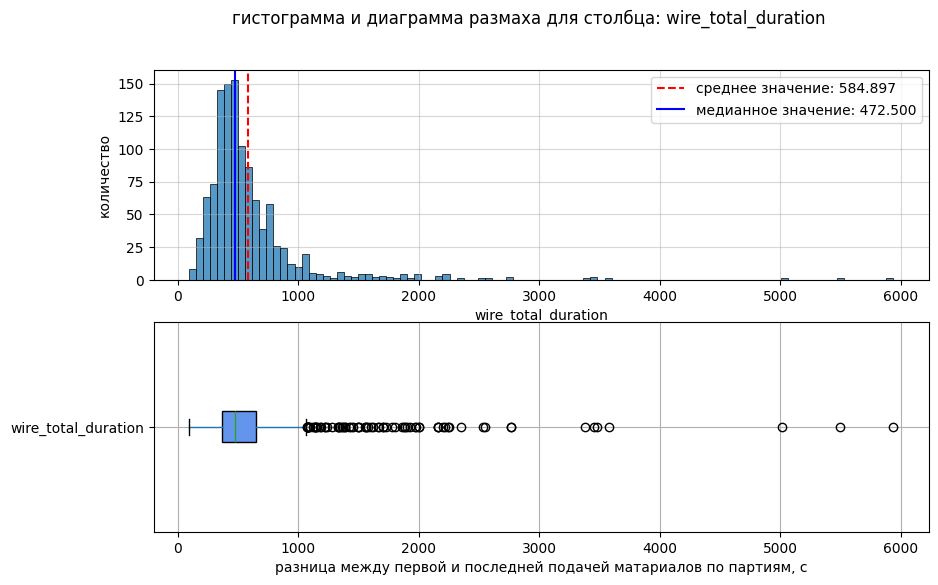

In [75]:
filtered_data_wire = data_wire_time[data_wire_time['wire_total_duration'] > 0]

visualization(filtered_data_wire , 'wire_total_duration', 
              'разница между первой и последней подачей матариалов по партиям, c')

\
Проведем агрегацию данных (создадим датафрейм `data_wire_aggregated`) с образованием признаков:
- `общ_объем_проволочных_материалов` - общий объем проволочных материалов по партиям;
- `количество_типов_проволочных_материалов` - количество типов проволочных материалов, добавленных в партию;
- `общ_время_подачи_проволочных_материалов` - диапазон времени между первой и последней подачей материалов по партиям в секундах при использовании только одного типа материалов или при одновременном добавлении нескольких примем время подачи равное 1 минуте);
- `avg_объем_проволочных_материалов` - средний объем подачи проволочных материалов в минуту.

In [76]:
# агрегация данных по партиям
data_wire_aggregated = pd.DataFrame(
    {'key' : data_wire['key']})

data_wire_aggregated['общ_объем_проволочных_материалов'] = data_wire[data_wire_columns].sum(axis=1)
data_wire_aggregated['количество_типов_проволочных_материалов'] = (data_wire[data_wire_columns] > 0).sum(axis=1)

# добавление столбца общ_время_подачи_проволочных_материалов
data_wire_aggregated = data_wire_aggregated.merge(
    data_wire_time[['key', 'wire_total_duration']],
    on='key',
    how='left'
)
data_wire_aggregated = data_wire_aggregated.rename(
    columns={'wire_total_duration': 'общ_время_подачи_проволочных_материалов'}
)

#  если использован только один тип материалов или при одновременном добавлении нескольких 
# примем медианное время подачи для партии
median_time = data_wire_aggregated[data_wire_aggregated['общ_время_подачи_проволочных_материалов'] > 0]\
    ['общ_время_подачи_проволочных_материалов'].median()
data_wire_aggregated['общ_время_подачи_проволочных_материалов'] = \
    data_wire_aggregated['общ_время_подачи_проволочных_материалов'].replace(0, median_time)


# добавление столбца avg_объем_проволочных_материалов
data_wire_aggregated['avg_объем_проволочных_материалов'] = data_wire_aggregated['общ_объем_проволочных_материалов'] \
    / (data_wire_aggregated['общ_время_подачи_проволочных_материалов'] / 60)

In [77]:
# заполнение пропусков
wire_aggregated_columns = [col for col in data_wire_aggregated if col != 'key']

data_wire_aggregated[wire_aggregated_columns] = data_wire_aggregated[wire_aggregated_columns].fillna(0)

In [78]:
# общая информация о полученном датафрейме
display(data_wire_aggregated.head(3))
data_wire_aggregated.info()

,key,общ_объем_проволочных_материалов,количество_типов_проволочных_материалов,общ_время_подачи_проволочных_материалов,avg_объем_проволочных_материалов
0,1,60.059998,1,472.5,7.626666
1,2,96.052315,1,472.5,12.197119
2,3,91.160157,1,472.5,11.575893


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3081 entries, 0 to 3080
Data columns (total 5 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   key                                      3081 non-null   int64  
 1   общ_объем_проволочных_материалов         3081 non-null   float64
 2   количество_типов_проволочных_материалов  3081 non-null   int64  
 3   общ_время_подачи_проволочных_материалов  3081 non-null   float64
 4   avg_объем_проволочных_материалов         3081 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 120.5 KB


### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

Таблица **data_arc**:
1. По результатам статистического анализа данных таблицы data_arc:
    - в столбце реактивная мощность обнаружено отрицательное значение;
    - временной диапазон с 2019-07-05 по 2019-09-06
    - заменено некорректное значение (отрицательное) в столбце Реактивная мощность на медианное значение всего столбца;
2. По результатам визуализации распределения признаков установлено, что:
	- в столбцах Активная мощность и Реактивная мощность присутствуют редкие выделяющиеся значения
3. Созданы и визуализированы признаки: 
	- времени нагрева в секундах (`длительность_нагрева`);
    - полной мощности (`полная_мощность`);
    - коэффициента мощности cos φ (`коэффициент_мощности`)
4. Для корректной агрегации данных по партиям созданы признаки:
    - активная_энергия;
    - реактивная_энергия;
    - полная_энергия.
5. - Проведена агрегация данных (создан датафрейм `data_arc_aggregated`) по партиям по результатам которой получены признаки:
	- `количество_нагревов` - общее количество нагревов партии;
	- `общ_длительность_нагрева` - общая длительность нагрева партии в секундах;
	- `активная_мощность_средн` - средневзвешенная активная мощность партии с учетом всех нагревов
	- `реактивная_мощность_средн` - средневзвешенная реактивная мощность партии с учетом всех нагревов
	- `полная_мощность_средн` - средневзвешенная полная мощность партии с учетом всех нагревов
	- ` активная_энергия ` - активная энергия, затраченная на все нагревы
	- ` реактивная_энергия ` - реактивная энергия, затраченная на все нагревы
	- ` полная_энергия ` - полная энергия, затраченная на все нагревы
	- ` коэффициент_мощности ` - средний коэффициент мощности партии.


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

Таблица data_bulk:
1. По результатам статистического анализа и визуализации распределения значений признаков установлено, что:
    - в данных присутствуют выделяющиеся значения (оставим их без изменений, т.к. эти значения возможны в данном технологическом процессе);


Таблица data_bulk_time:
1. По результатам проверки временных диапазонов каждого признака и соотнесения с временным диапазоном таблицы data_arc выявлено одно, выходящее за диапазон. Возможно, это связано с асинхронностью датчиков.
2. По результатам визуализации распределения диапазона времени между первой и последней подачей материалов по партиям в данных выявлены выделяющиеся значения превышающие 4000 с., что возможно из-за ошибок в данных или обусловлено длительным легированием партии.
3. Проведена агрегация данных (создан датафрейм `data_bulk_aggregated`) с образованием новых признаков:
	- `общ_объем_сыпучи_материалов` - общий объем сыпучих материалов по партиям;
	- `количество_типов_материалов` - количество типов материалов, добавленных в партию;
	- `общ_время_подачи_сыпучих_материалов` - диапазон времени между первой и последней подачей материалов по партиям в секундах (при использовании только одного типа материалов или при одновременном добавлении нескольких принято время подачи равное 1 минуте);
	- `avg_объем_сыпучих_материалов` - средний объем подачи сыпучих материалов в минуту.


Таблица data_gas:
- По результатам визуализации распределения объема подаваемого газа выявлены выделяющиеся значения больше 40, вероятно это связано с большим количеством добавляемых материалов и, соответственно, большим количеством циклов продувки стали.


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

Таблица data_temp:
- По результатам статистического анализы выявлены пропущенные последние значения температуры у 739 партий (данные партии удалены из данных, т.к. заполнение пропусков повлияет на качество модели). 
- Также удалены партии со значением температуры меньше 1500.
- Проведена агрегация данных (создан датафрейм `data_temp_aggregated`) с выделением целевой переменной (при агрегации выбраны партии, у которых не менее двух замеров температуры):
	- `начальная_температура` - первая измеренная температура;
    - **`температура` - последняя измеренная температура (целевая переменная)**;
    - `изменение_температуры` - изменение температуры между последним и первым замерами;
    - `время_между_замерами` - время между первым и последним измерением температуры в секунах.
- В датафрейме `data_temp_aggregated` 2471 партия.



Таблица data_wire:
- По результатам статистического анализа и визуализации распределения в данных присутствуют выделяющиеся значения.

Таблица data_wire_time:
1. По результатам проверки временных диапазонов каждого признака и соотнесения с временным диапазоном таблицы data_arc не выявлено значений, выходящих за диапазон
2. По результатам визуализации распределения диапазона времени между первой и последней подачей материалов по партиям в данных выявлены выделяющиеся значения превышающие 2000 с., что возможно из-за ошибок в данных или обусловлено длительным легированием партии.
3. Проведена агрегация данных (создан датафрейм `data_wire_aggregated`) с образованием новых признаков:
	- `общ_объем_проволочных_материалов` - общий объем проволочных материалов по партиям;
    - `количество_типов_проволочных_материалов` - количество типов проволочных материалов, добавленных в партию;
    - `общ_время_подачи_проволочных_материалов` - диапазон времени между первой и последней подачей материалов по партиям в секундах при использовании только одного типа материалов или при одновременном добавлении нескольких примем медианное время подачи для партии);
    - `avg_объем_проволочных_материалов` - средний объем подачи проволочных материалов в минуту.


## Объединение данных

На данном этапе будет проведена работа по:
- объединению данных в единую таблицу
- корреляционному и исследовательскому анализу данных получившегося датафрейма

\
Объединение данных проведем путем поочередного присоединения таблиц (по значениям `key`):
- сначала присоединим `data_arc` к `data_temp` (т.к. из data_temp удалено значительное количество партий);
- затем присоединим `data_bulk_aggregated`, `data_wire_aggregated` `data_gas`

In [79]:
# уникальные партии датафреймов
keys_temp = set(data_temp_aggregated['key'])
keys_arc = set(data_arc_aggregated['key'])
keys_bulk = set(data_bulk_aggregated['key'])
keys_wire = set(data_wire_aggregated['key'])
keys_gas = set(data_gas['key'])

In [80]:
# количество уникальных партий по таблицам
print(f'data_temp_aggregated:     {len(keys_temp)} ключей')
print(f'data_arc_aggregated:      {len(keys_arc)} ключей')
print(f'data_bulk_aggregated:     {len(keys_bulk)} ключей')
print(f'data_wire_aggregated:     {len(keys_wire)} ключей')
print(f'data_gas:                 {len(keys_gas)} ключей')

data_temp_aggregated:     2471 ключей
data_arc_aggregated:      3214 ключей
data_bulk_aggregated:     3129 ключей
data_wire_aggregated:     3081 ключей
data_gas:                 3239 ключей


In [81]:
print('партии из data_temp_aggregated, отсутствующие в других Датафреймах:')
print(f'отсутствуют в data_arc_aggregated:  {len(keys_temp - keys_arc)}')
print(f'отсутствуют в data_bulk_aggregated: {len(keys_temp - keys_bulk)}')
print(f'отсутствуют в data_wire_aggregated: {len(keys_temp - keys_wire)}')
print(f'отсутствуют в data_gas:             {len(keys_temp - keys_gas)}')

партии из data_temp_aggregated, отсутствующие в других Датафреймах:
отсутствуют в data_arc_aggregated:  0
отсутствуют в data_bulk_aggregated: 68
отсутствуют в data_wire_aggregated: 103
отсутствуют в data_gas:             2


### Итоговый датафрейм (final_df)

In [82]:
keys_common = set(data_temp_aggregated['key']) & set(data_arc_aggregated['key']) & \
              set(data_bulk_aggregated['key']) & set(data_wire_aggregated['key']) & \
              set(data_gas['key'])

print(f'количество партий, присутствующих во всех таблицах: {len(keys_common)}')

количество партий, присутствующих во всех таблицах: 2325


In [83]:
final_df = data_temp_aggregated[data_temp_aggregated['key'].isin(keys_common)] \
    .merge(data_arc_aggregated, on='key') \
    .merge(data_bulk_aggregated, on='key') \
    .merge(data_wire_aggregated, on='key') \
    .merge(data_gas, on='key')

In [84]:
# переменование столбца
final_df = final_df.rename(
    columns={'Газ 1': 'объем_газа'}
)

In [85]:
# проверка наличия дубликатов 
final_df.duplicated().sum()

np.int64(0)

In [86]:
# общая информация о полученном датафрейме
display(final_df.head(10))
final_df.info()

,key,начальная_температура,температура,количество_замеров_температуры,время_между_замерами,количество_нагревов,общ_длительность_нагрева,активная_мощность_средн,реактивная_мощность_средн,полная_мощность_средн,активная_энергия,реактивная_энергия,полная_энергия,коэффициент_мощности,общ_объем_сыпучих_материалов,количество_типов_сыпучих_материалов,общ_время_подачи_сыпучих_материалов,avg_объем_сыпучих_материалов,средний_объем_сыпучих_материалов,общ_объем_проволочных_материалов,количество_типов_проволочных_материалов,общ_время_подачи_проволочных_материалов,avg_объем_проволочных_материалов,объем_газа
0,1,1571,1613,6,1714,5,1098.0,0.572511,0.404817,0.701532,628.616930,444.489437,770.282114,0.816686,553,4,1085.0,30.580645,138.250000,60.059998,1,472.5,7.626666,29.749986
1,2,1581,1602,5,1265,4,811.0,0.487400,0.338705,0.594032,395.281800,274.689995,481.760005,0.825276,582,4,1000.0,34.920000,145.500000,96.052315,1,472.5,12.197119,12.555561
2,3,1596,1599,6,1753,5,655.0,0.888206,0.653495,1.103569,581.774624,428.038924,722.837668,0.809724,544,4,983.0,33.204476,136.000000,91.160157,1,472.5,11.575893,28.554793
3,4,1601,1625,5,1220,4,741.0,0.733752,0.558626,0.922342,543.710274,413.941977,683.455597,0.793923,595,4,878.0,40.660592,148.750000,89.063515,1,472.5,11.309653,18.841219
4,5,1576,1602,5,1536,4,869.0,0.474316,0.348758,0.589379,412.180480,303.070918,512.169934,0.796818,584,4,205.0,170.926829,146.000000,98.352796,2,310.0,19.036025,5.413692
5,6,1543,1596,5,1497,4,952.0,0.726544,0.498617,0.881545,691.669688,474.683338,839.231310,0.817260,676,4,1250.0,32.448000,169.000000,108.224477,2,515.0,12.608677,11.273392
6,7,1586,1599,5,1744,4,673.0,0.730387,0.544073,0.911704,491.550467,366.161046,613.576982,0.802491,627,4,1348.0,27.908012,156.750000,98.061600,1,472.5,12.452267,9.836267
7,8,1577,1598,5,1615,4,913.0,0.543918,0.403947,0.678127,496.597268,368.803429,619.129542,0.799289,914,4,745.0,73.610738,228.500000,155.282394,1,472.5,19.718399,15.171553
8,9,1587,1592,6,1811,5,625.0,0.743129,0.528412,0.912182,464.455338,330.257804,570.113675,0.813283,526,4,629.0,50.174881,131.500000,122.536960,2,367.0,20.033290,8.216623
9,10,1574,1593,7,1551,6,825.0,0.532170,0.367312,0.646645,439.040344,303.032346,533.482050,0.822895,509,3,495.0,61.696970,169.666667,93.620796,2,264.0,21.277454,6.529891


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 24 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   key                                      2325 non-null   int64  
 1   начальная_температура                    2325 non-null   int64  
 2   температура                              2325 non-null   int64  
 3   количество_замеров_температуры           2325 non-null   int64  
 4   время_между_замерами                     2325 non-null   int64  
 5   количество_нагревов                      2325 non-null   int64  
 6   общ_длительность_нагрева                 2325 non-null   float64
 7   активная_мощность_средн                  2325 non-null   float64
 8   реактивная_мощность_средн                2325 non-null   float64
 9   полная_мощность_средн                    2325 non-null   float64
 10  активная_энергия                         2325 no

### Корреляционный анализ данных

Корреляционный анализ признаков выполним с помощью матрицы корреляции из библиотеки phik

In [87]:
# список непрерывных количественных признаков
interval_cols = [col for col in final_df if col not in ['количество_замеров_температуры',
                                                        'количество_нагревов',
                                                        'количество_типов_сыпучих_материалов',
                                                        'количество_типов_проволочных_материалов']]                                                        

In [88]:
# матрица корреляции таблицы final_df
data_plot = final_df.drop(columns='key').phik_matrix(interval_cols=interval_cols)

mask_final_df = np.triu(np.ones_like(data_plot, dtype=bool), k=1)

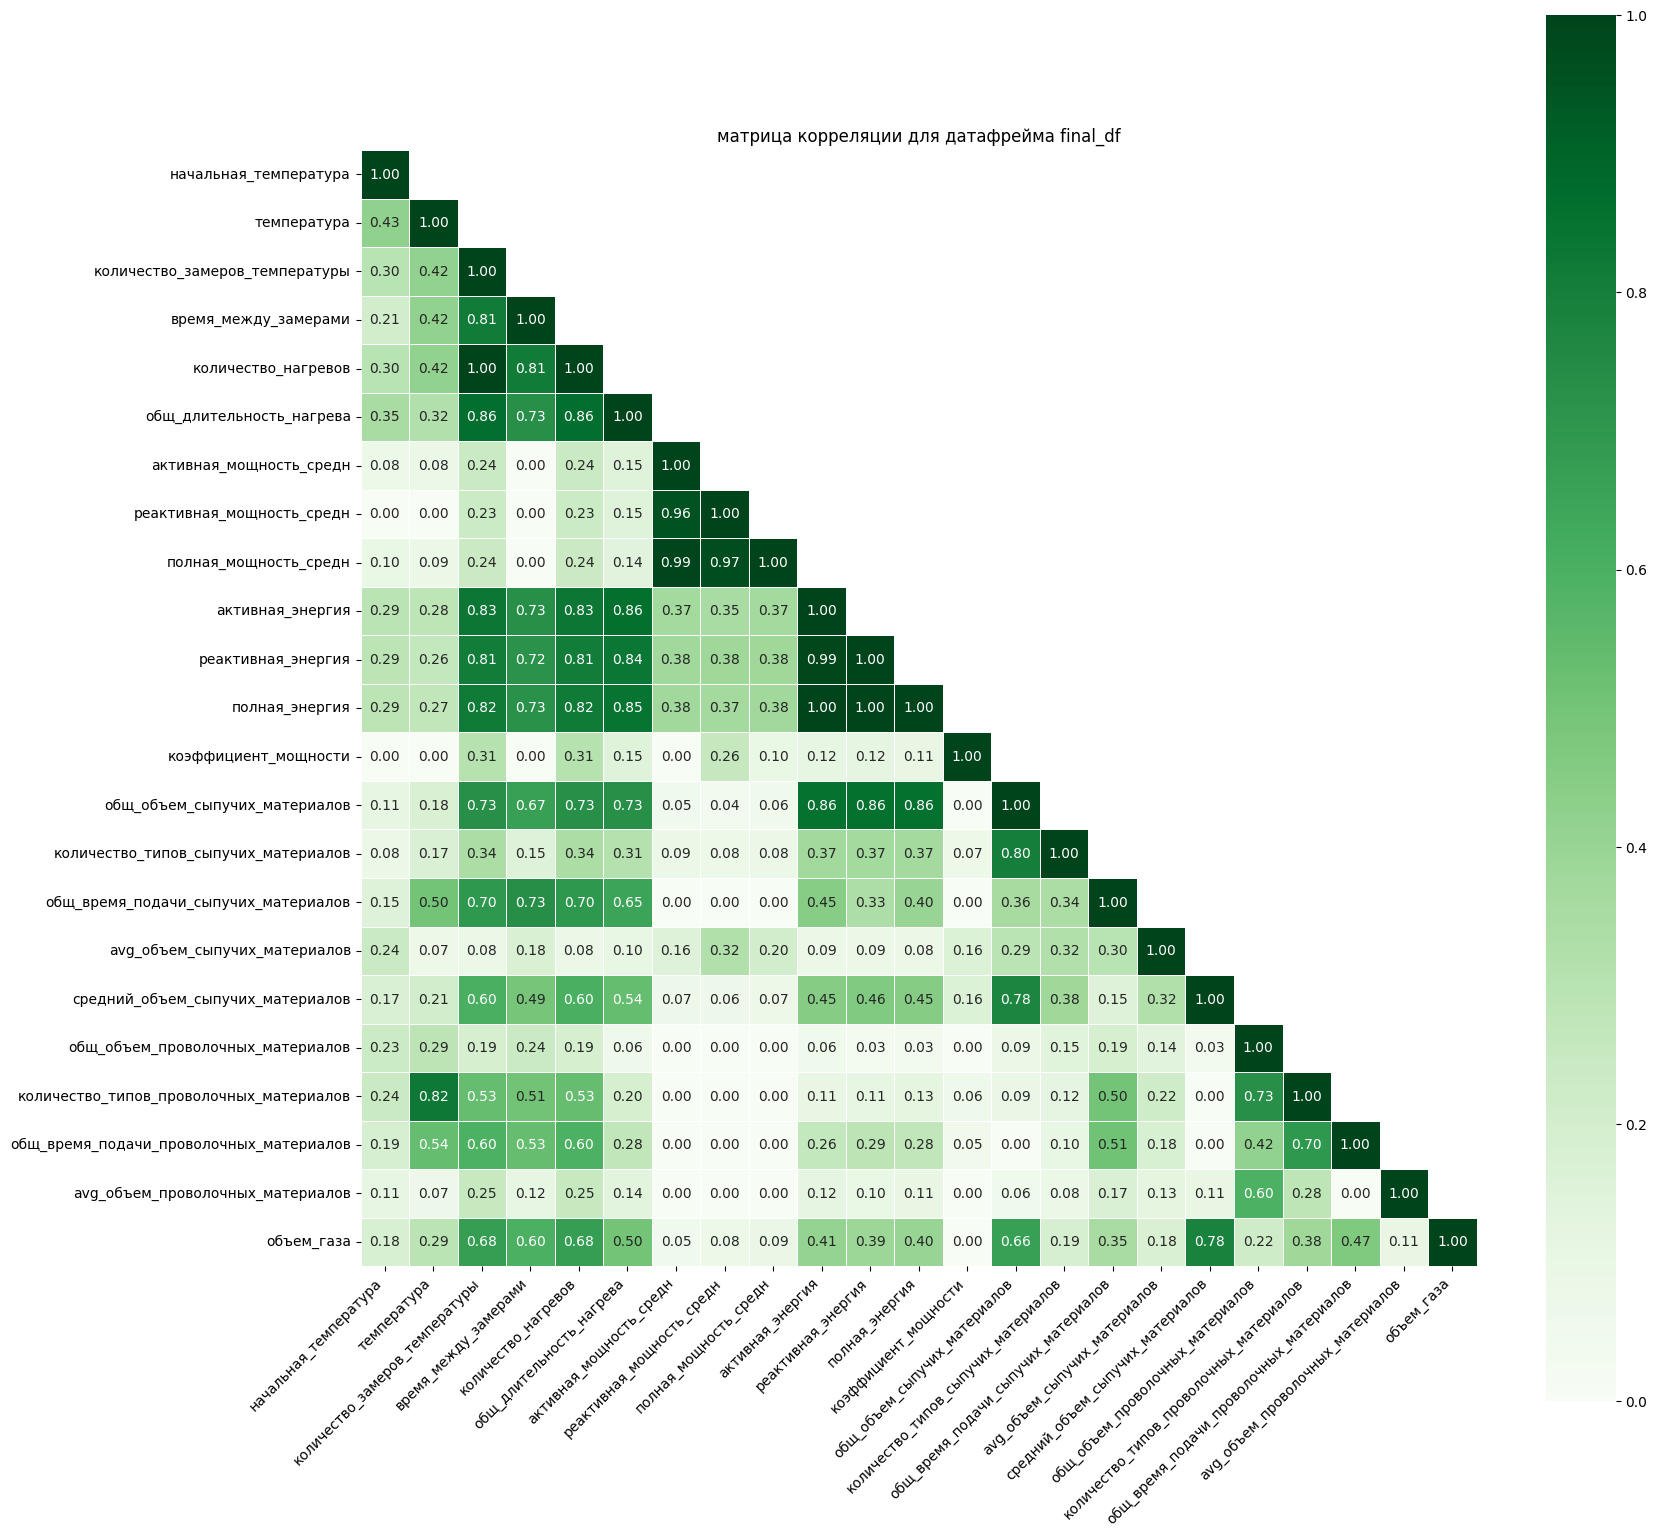

In [89]:
# визуализация матрицы корреляции таблицы final_df
plt.figure(figsize=(18, 18))
sns.heatmap(data_plot,
            mask=mask_final_df,
            annot=True,
            cmap='Greens',
            square=True,
            linewidths=0.5,
            fmt=".2f"
           )
# настройка графика
plt.title('матрица корреляции для датафрейма final_df')
plt.xticks(rotation=45, ha='right')

plt.savefig('heatmap.png', dpi=400, bbox_inches='tight')
plt.show()

In [90]:
# удалим коррелирующие признаки
final_df = final_df.drop(['количество_замеров_температуры','активная_мощность_средн', 
                              'реактивная_мощность_средн', 'активная_энергия', 
                              'реактивная_энергия'], axis=1)

### Исследовательский анализ данных

Проведем статистический анализ данных и визуализируем распределение признаков с обработкой аномальных значений (при необходимости)

In [91]:
# статистический анализ
final_df.describe()

,key,начальная_температура,температура,время_между_замерами,количество_нагревов,общ_длительность_нагрева,полная_мощность_средн,полная_энергия,коэффициент_мощности,общ_объем_сыпучих_материалов,количество_типов_сыпучих_материалов,общ_время_подачи_сыпучих_материалов,avg_объем_сыпучих_материалов,средний_объем_сыпучих_материалов,общ_объем_проволочных_материалов,количество_типов_проволочных_материалов,общ_время_подачи_проволочных_материалов,avg_объем_проволочных_материалов,объем_газа
count,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000,2325.000000
mean,1251.512258,1587.365161,1593.366022,2323.419785,4.696344,808.035269,0.826561,670.099581,0.805477,609.964731,3.593978,1100.888602,42.869387,165.487629,125.181774,1.396989,512.708387,16.009420,11.378942
std,715.099053,23.623144,11.209581,1385.569302,1.605930,340.829330,0.174368,319.522140,0.013952,287.569669,1.224168,731.130348,31.884931,53.819709,63.685486,0.564505,276.817233,10.278405,6.395632
min,1.000000,1519.000000,1541.000000,339.000000,1.000000,57.000000,0.331897,33.430208,0.739789,19.000000,1.000000,82.000000,1.211477,19.000000,1.918800,1.000000,90.000000,0.243657,0.008399
25%,629.000000,1571.000000,1587.000000,1581.000000,4.000000,581.000000,0.697644,457.872635,0.796798,440.000000,3.000000,696.000000,23.400000,130.800000,89.013596,1.000000,472.500000,10.693974,7.282948
50%,1255.000000,1587.000000,1593.000000,2046.000000,5.000000,778.000000,0.811683,630.913482,0.806009,609.000000,4.000000,941.000000,36.501129,157.200000,116.101440,1.000000,472.500000,14.249386,10.100950
75%,1868.000000,1603.000000,1598.000000,2793.000000,6.000000,993.000000,0.935222,841.644330,0.814801,796.000000,4.000000,1340.000000,53.503650,197.750000,151.550872,2.000000,472.500000,18.936322,14.217691
max,2499.000000,1660.000000,1653.000000,23674.000000,16.000000,4189.000000,1.567715,4546.405812,0.857042,3235.000000,7.000000,13683.000000,306.506024,539.166667,568.777664,5.000000,5937.000000,182.196215,77.995040


In [92]:
# список дискретных числовых признаков
cat_columns = ['количество_нагревов',
               'количество_типов_сыпучих_материалов',
               'количество_типов_проволочных_материалов']

# обновление списка непрерывных количественных признаков
interval_cols = [col for col in final_df if col not in ['key',
                                                        'количество_нагревов',
                                                        'количество_типов_сыпучих_материалов',
                                                        'количество_типов_проволочных_материалов']]

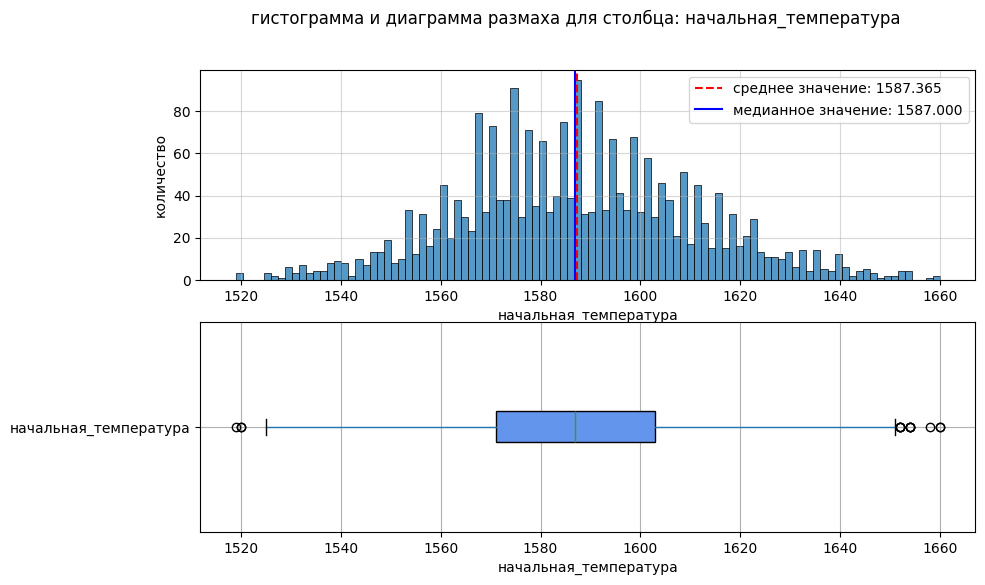

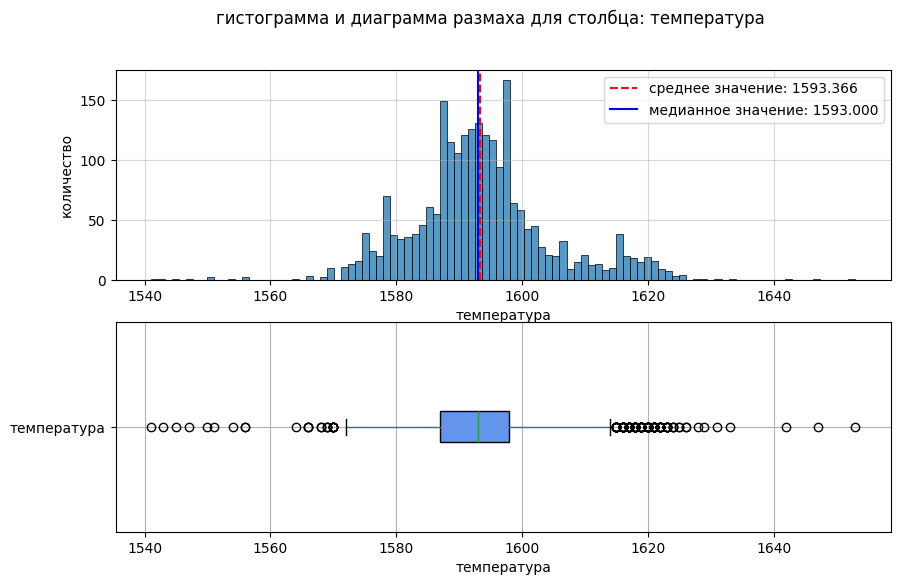

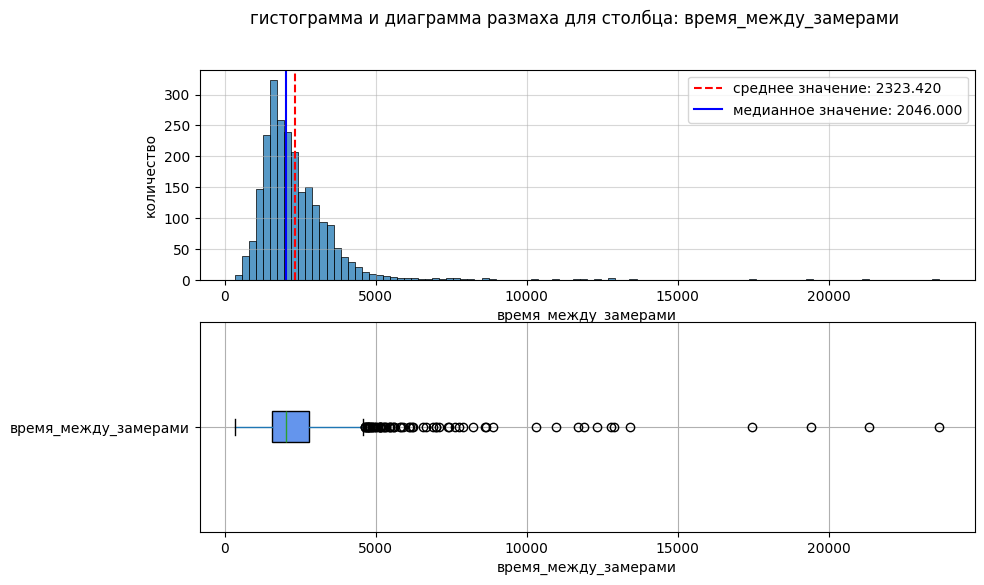

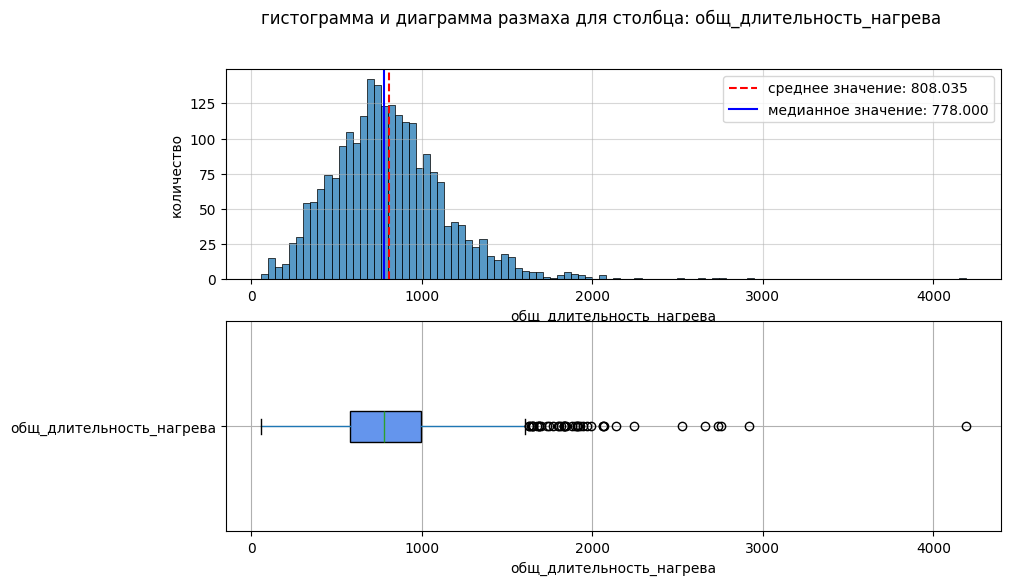

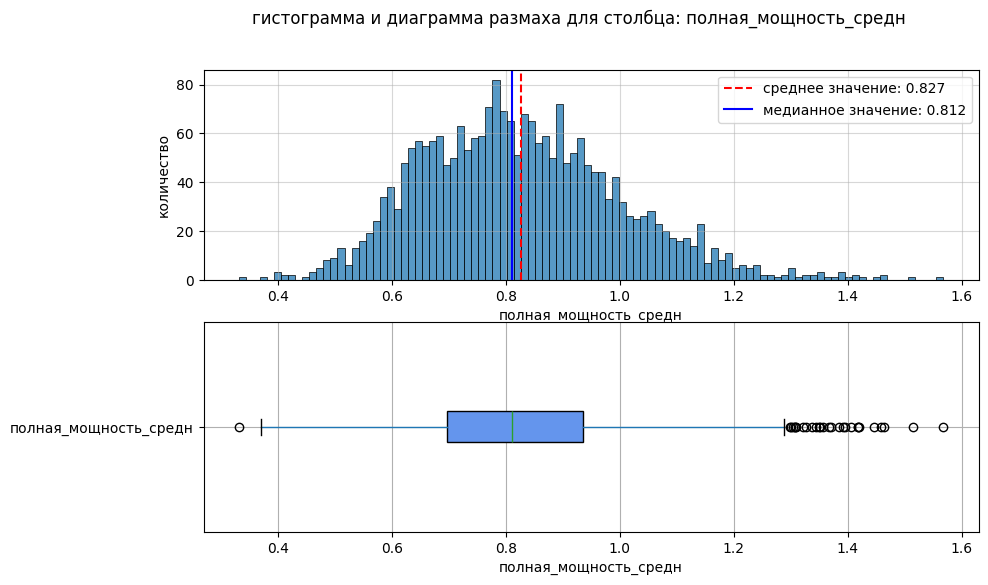

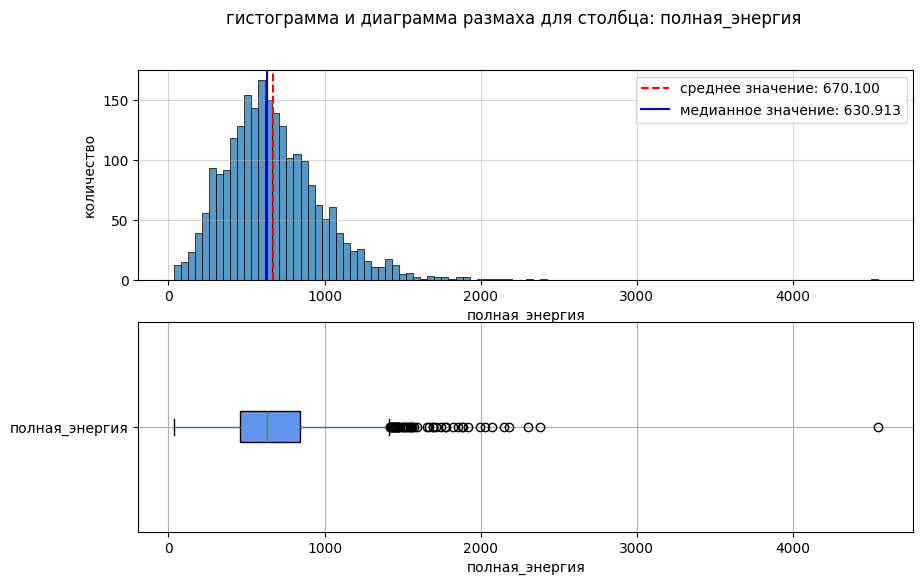

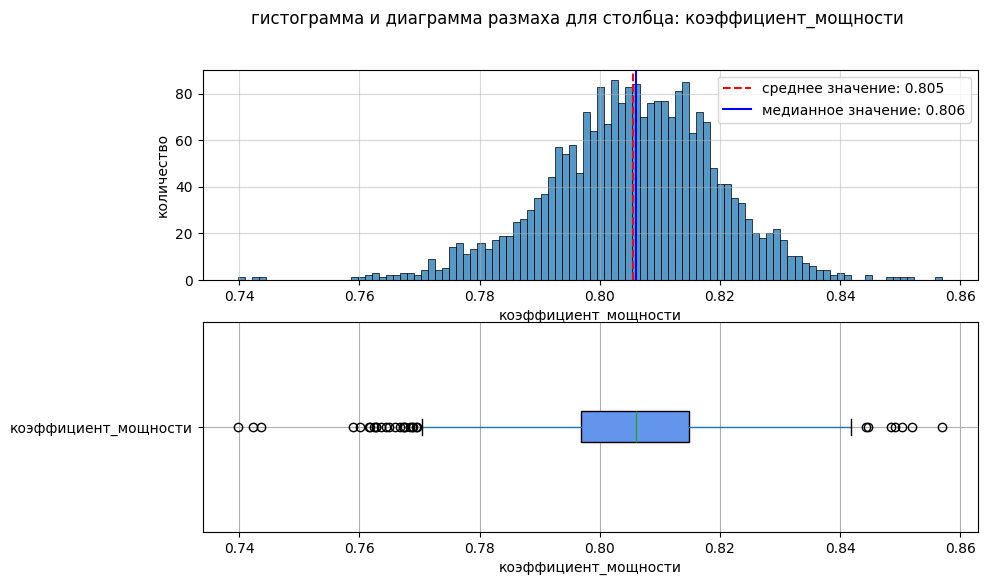

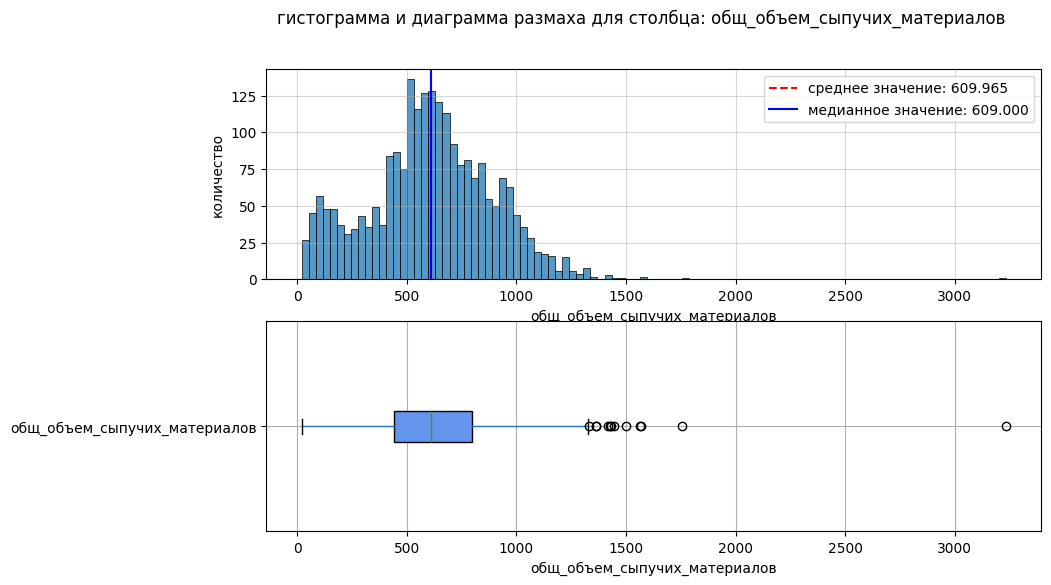

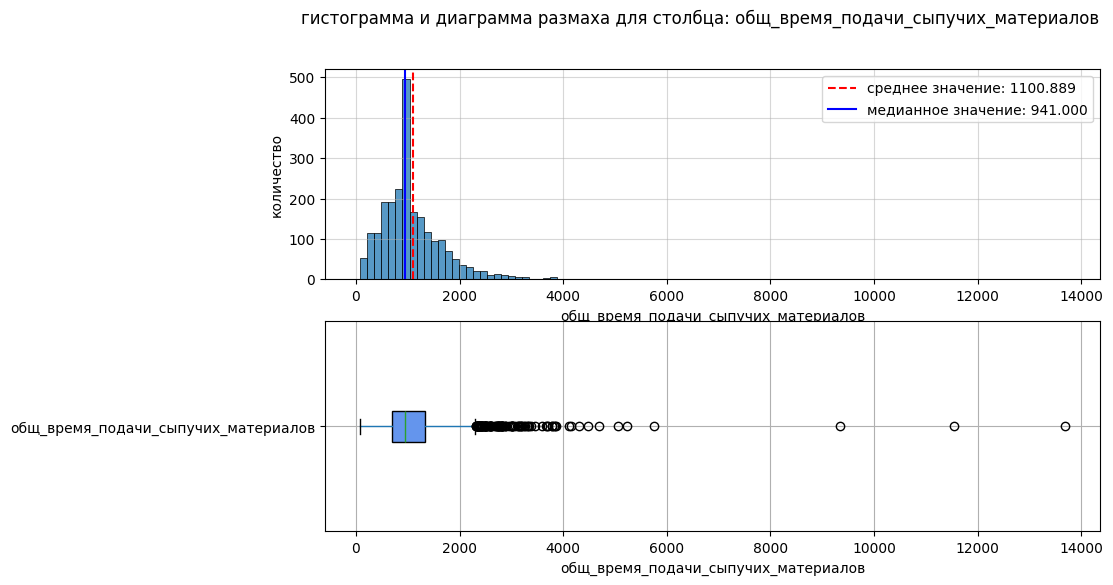

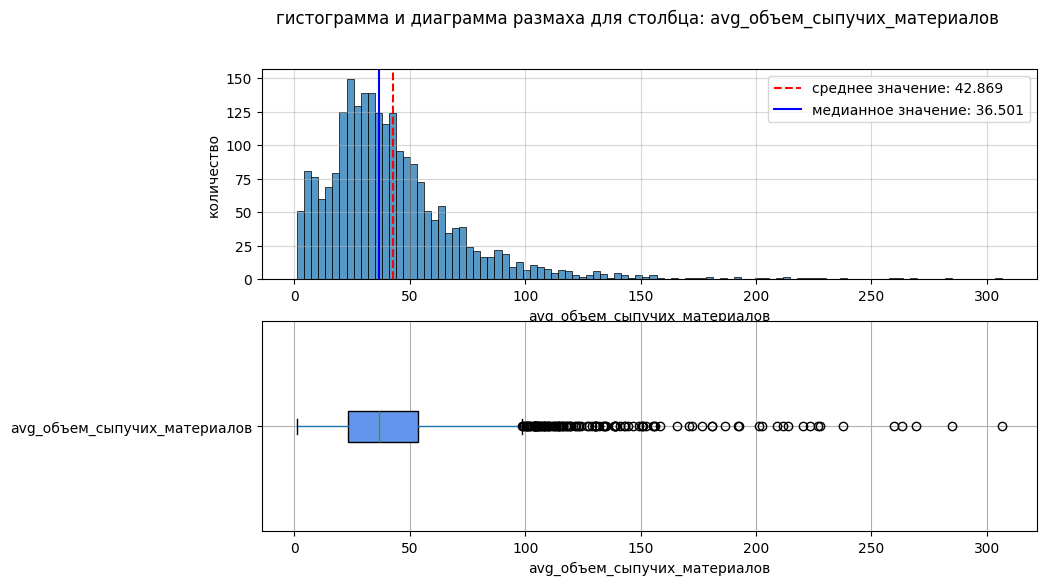

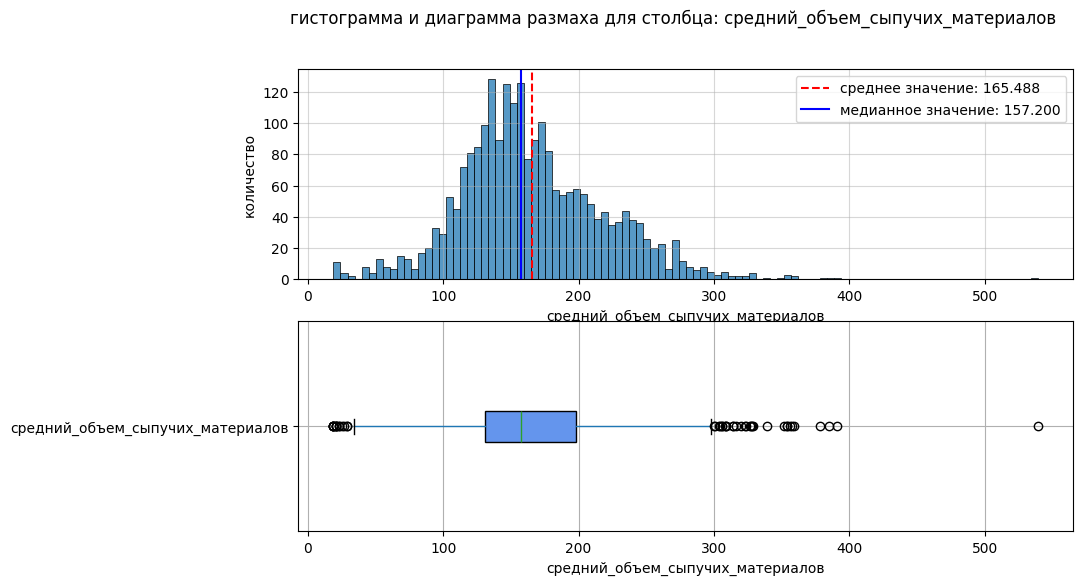

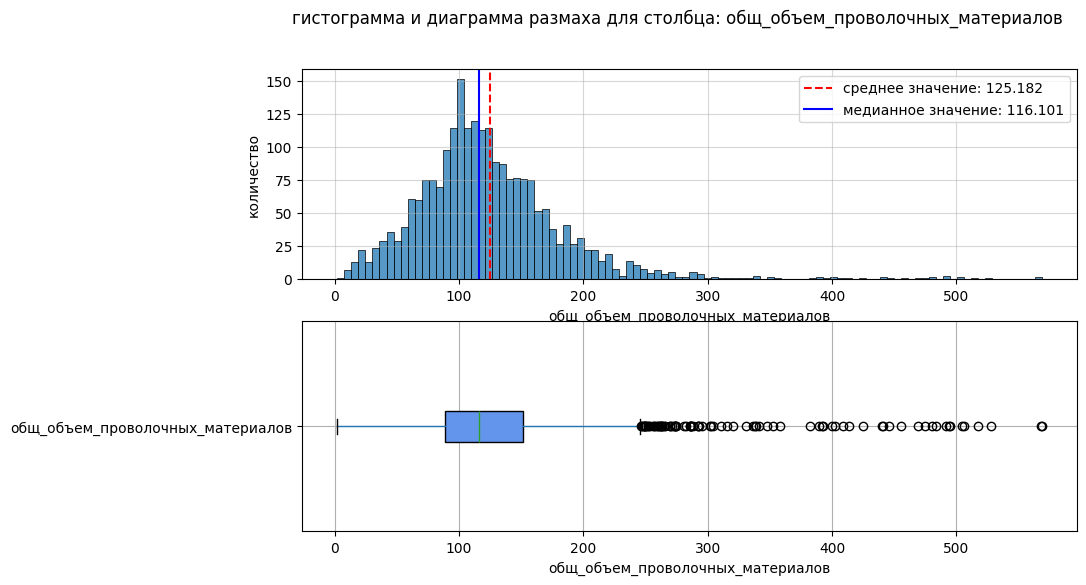

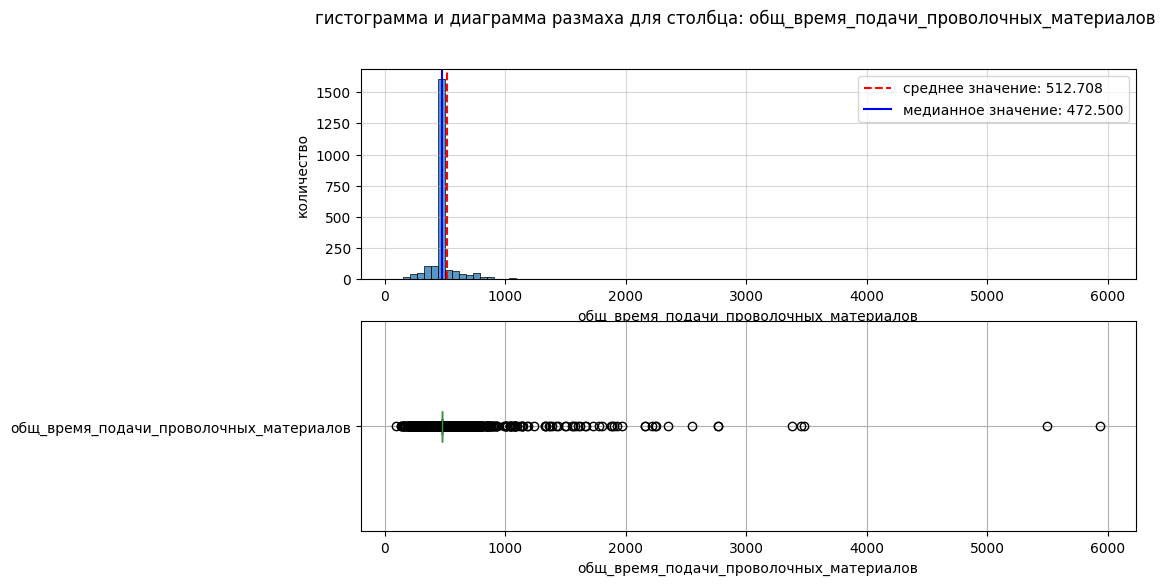

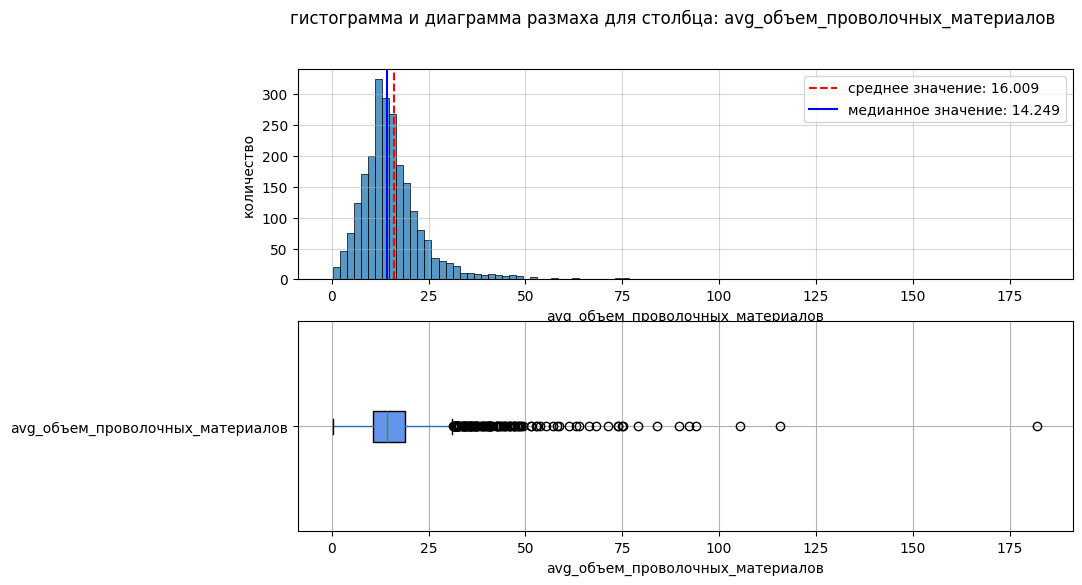

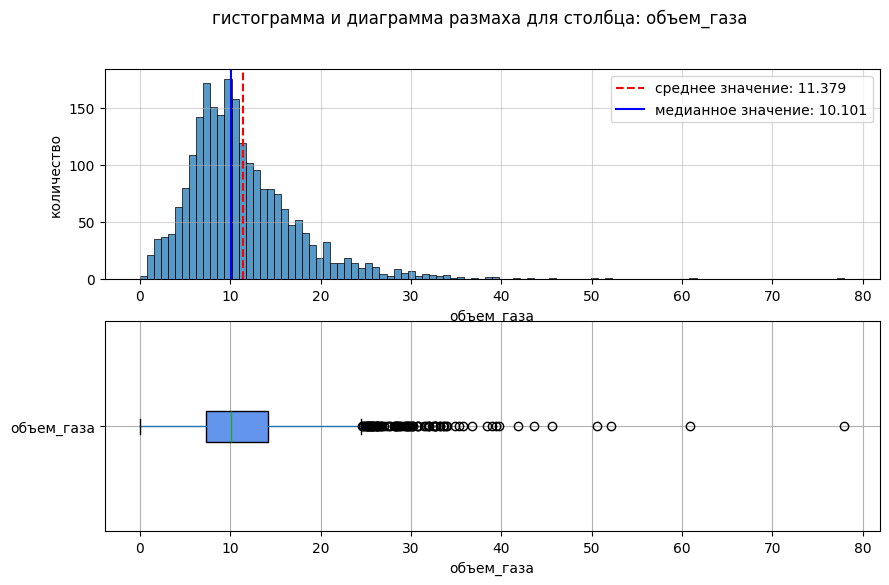

In [93]:
# визуализация непрерывных количественных признаков
for col in interval_cols:
    visualization(final_df, col, col)

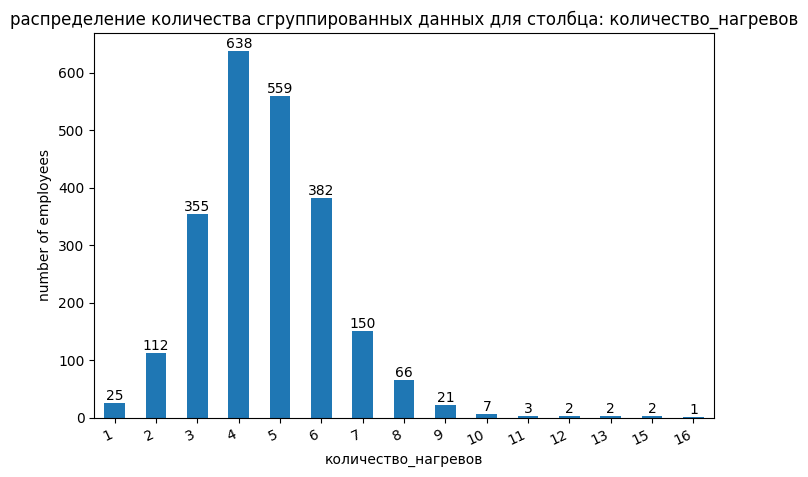

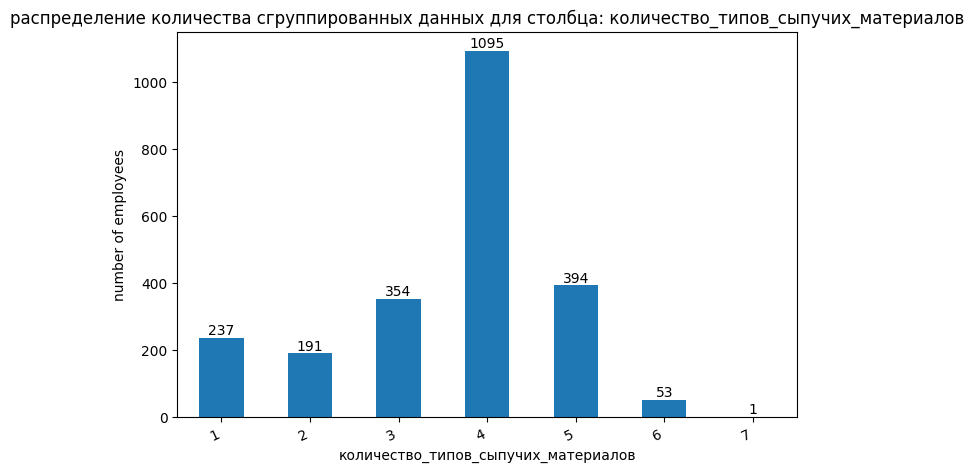

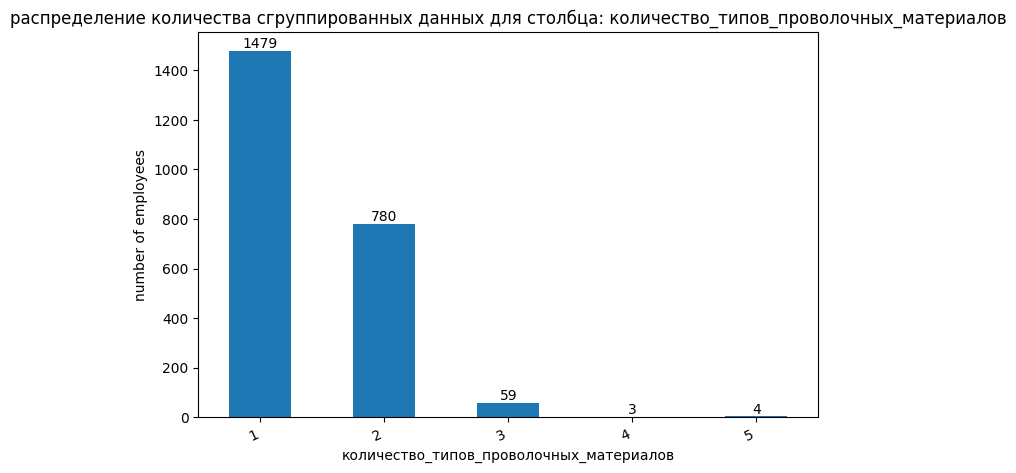

In [94]:
# визуализация дискретных количественных признаков
for col in cat_columns:
    visualization(final_df, col, col, num_col=False)

### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

1. Проведено объединение данных только по партиям, присутствующим во всех таблицах (с учетом ТЗ *«во все партии точно добавлялись сыпучие и проволочные материалы, везде была выполнена продувка газом и сплав всегда нагревался»*). В объединенном датафрейме 2325 партий.

2. По результатам корреляционного анализа данных из датафрейма удалены коррелирующие признаки:
- количество_замеров_температуры
- активная_мощность_средн;
- реактивная_мощность_средн;
- активная_энергия;
- реактивная_энергия.

3. По результатам исследовательского анализа данных установлено, что:
- в данных обнаружены выделяющиеся значения (оставим их без изменений, т.к. проводили обработку на этапе поочередного исследования таблиц);
- 27.5% партий подвергались нагреву 4 раза, 24% партий нагревались 5 раз, 16% партий нагревались 6 раз; 15% партий нагревались 3 раза;
- в 47% партий добавлялось 4 типа сыпучих материалов, в 17% партий добавлялось 5 типов сыпучих материалов, в 16% партий 3 типа материалов, в 9% партий 1 тип сыпучего материала;
- в 63% партий добавлялся 1 тип проволочных материалов, в 34% партий добавлялось 2 типа материалов, в 2,5% партий добавлялось 3 типа проволочных материалов.



## Подготовка данных для модели МО

На данном этапе будет проведена работа по: 
- разделению данных не тренировочную и тестовую выборки;
- подготовке данных для обучения моделей МО (масшабирование количественных признаков и кодирование категориальных).\
Для масшабирования используем StandardScaler, для кодирования OneHotEncoder.

Количественные признаки: 
`начальная_температура`, `общ_длительность_нагрева`, `полная_мощность_средн`, `коэффициент_мощности`,
`общ_объем_сыпучих_материалов`, `общ_время_подачи_сыпучих_материалов`, `avg_объем_сыпучих_материалов`, `общ_объем_проволочных_материалов`, 
`общ_время_подачи_проволочных_материалов`, `avg_объем_проволочных_материалов`, `объем_газа`;\
\
В качестве категориальных примем дискретные числовые признаки: `количество_нагревов`, `количество_типов_сыпучих_материалов`, `количество_типов_проволочных_материалов`

### Пайплайн подготовки данных

In [95]:
# признаки для масштабирования с использованием StandardScaler
num_columns = [col for col in final_df if col not in ['key',
                                                      'температура',
                                                      'количество_нагревов',
                                                      'количество_типов_сыпучих_материалов',
                                                      'количество_типов_проволочных_материалов']]

# признаки для кодирования с использованием OneHotEncoder
ohe_columns =  ['количество_нагревов',
                'количество_типов_сыпучих_материалов',
                'количество_типов_проволочных_материалов']

In [96]:
# пайплайн для подготовки признаков из списка ohe_col
ohe_pipe = Pipeline(
    [
        ('simpleimputer_before_ohe', 
        SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ]
)

In [97]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('num', StandardScaler(), num_columns)
    ],
    remainder='passthrough'
)

### Инициализация выборок

In [98]:
X = final_df.drop(['key', 'температура'], axis=1)
y = final_df['температура']
    
# разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE
)

In [99]:
# выделение валидационной выборки из X_train и y_train
# для обучения нейросети, чтобы не задействовать тестовую выборку
X_train_network, X_val, y_train_network, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [100]:
# проверка наличия дубликатов в выборках
print('количество дубликатов в тренировочной выборке:', X_train.duplicated().sum())
print('количество дубликатов в тестовой выборке:', X_test.duplicated().sum())

количество дубликатов в тренировочной выборке: 0
количество дубликатов в тестовой выборке: 0


In [101]:
# проверка размерности выборок
X_train.shape, X_test.shape

((1743, 17), (582, 17))

In [102]:
y_train.shape, y_test.shape

((1743,), (582,))

### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

Проведена работа по:
1.  написанию пайплайна по масштабированию количественных признаков и кодированию категориальных;
- количественные признаки: 
    - `начальная_температура`,
    - `изменение_температуры`,
    - `время_между_замерами`,
    - `общ_длительность_нагрева`, 
    - `полная_мощность_средн`,
    - `полная_энергия`,
    - `коэффициент_мощности`,
    - `общ_объем_сыпучих_материалов`,
    - `общ_время_подачи_сыпучих_материалов`,
    - `avg_объем_сыпучих_материалов`, 
    - `общ_объем_проволочных_материалов`, 
    - `общ_время_подачи_проволочных_материалов`,
    - `avg_объем_проволочных_материалов`, 
    - `объем_газа`.
- категориальные признаки:
	- `количество_нагревов`, 
    - `количество_типов_сыпучих_материалов`,
    - `количество_типов_проволочных_материалов`
2. Проведено разделение данных на тренировочную и тестовую выборки в соотношении 75:25.

## Обучение моделей МО

- На данном этапе будет проведена работа по инициализации и обучению моделей МО с различными гиперпараметрами.\
Используем модели: DecisionTreeRegressor, LGBMRegressor и полносвязную нейросеть;
- Подбор наилучших гиперпараметров будем производить на основании значения метрики с помощью библиотеки optuna;
- В качесте основной метрики используем MAE.

In [103]:
# скрытие сообщений (кроме ошибок)
optuna.logging.set_verbosity(optuna.logging.CRITICAL)

In [104]:
# функция подбора гиперпараметров для DecisionTreeRegressor и XGBRegressor
def objective_tree(trial, model_name, X_train, y_train, X_test=None, y_test=None):
    '''
    функция подбора гиперпараметров для 
    моделей DecisionTreeRegressor и XGBRegressor
    на основании значения метрики MAE при короссвалидации

    model_name:
    decision_tree - DecisionTreeRegressor;
    xgb - XGBRegressor
    '''
    # гиперпараметры для DecisionTreeRegressor
    if model_name == 'decision_tree':
        params = {
            'criterion': trial.suggest_categorical('criterion', ['squared_error', 
                                                                 'friedman_mse',
                                                                 'absolute_error']),
            'max_depth' :  trial.suggest_int('max_depth', 3, 20),
            'min_samples_split' : trial.suggest_int('min_samples_split', 2, 16),
            'min_samples_leaf' : trial.suggest_int('min_samples_leaf', 1, 12),
            'max_leaf_nodes' : trial.suggest_int('max_leaf_nodes', 10, 200)
        }
        model = DecisionTreeRegressor(**params, random_state=RANDOM_STATE)

     # гиперпараметры для XGBRegressor
    elif model_name == 'xgb':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 15),
            'learning_rate': trial.suggest_loguniform('learning_rate', 0.001, 0.3),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-5, 1.0),
            'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-5, 1.0),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_loguniform('gamma', 1e-6, 1.0),
            'max_leaves': trial.suggest_int('max_leaves', 31, 255)
        }
        model = XGBRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

    # гиперпараметры для RandomForestRegressor
    elif model_name == 'rf':
        bootstrap = trial.suggest_categorical('bootstrap', [True, False])
        params = {
            'criterion': trial.suggest_categorical('criterion', ['squared_error',
                                                                 'friedman_mse',
                                                                 'absolute_error',
                                                                 'poisson']),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None, 0.3, 0.5, 0.7, 0.9]),
            'n_estimators': trial.suggest_int('n_estimators', 50, 500),
            'max_leaf_nodes': trial.suggest_int('max_leaf_nodes', 10, 255),
            'min_weight_fraction_leaf': trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5),
            'min_impurity_decrease': trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-2),
            'bootstrap': bootstrap,
            'ccp_alpha': trial.suggest_loguniform('ccp_alpha', 1e-6, 1e-1)
        }
        if bootstrap:
            params['max_samples'] = trial.suggest_float('max_samples', 0.5, 1.0)
        
        model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)

    # использование пайплайна подготовки данных
    preprocessor = data_preprocessor
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # метрики
    scoring = {
        'mse': 'neg_mean_squared_error',
        'mae': 'neg_mean_absolute_error',
        'r2': 'r2'
    }

    # кроссвалидация
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_validate(model, X_train, y_train, cv=cv, 
                            scoring=scoring, n_jobs=-1, return_train_score=False)

    # значения метрик при кроссвалидации
    mse_scores = -scores['test_mse'] 
    mae_scores = -scores['test_mae']
    r2_scores = scores['test_r2']
    
    # среднее значение метрик
    metrics = {
        'mse' : round(np.mean(mse_scores), 3),
        'mae' : round(np.mean(mae_scores), 3),
        'r2' : round(np.mean(r2_scores), 3)
    }

    # сохранение метрик
    for name, value in metrics.items():
        trial.set_user_attr(name, value)

    return metrics['mae']

### Обучение DecisionTreeRegressor

In [105]:
start = time.time()

study_decision_tree = optuna.create_study(direction='minimize')
study_decision_tree.optimize(lambda trial: objective_tree(trial, 'decision_tree', X_train, y_train), 
                  n_trials=30, show_progress_bar=True)

print(f"время подбора гиперпараметров: {time.time() - start:.2f}\n")
print('лучшие параметры', study_decision_tree.best_params)
print('\nлучшее значение MAE при кроссвалидации:', study_decision_tree.best_value)

  0%|          | 0/30 [00:00<?, ?it/s]

время подбора гиперпараметров: 50.88

лучшие параметры {'criterion': 'absolute_error', 'max_depth': 5, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_leaf_nodes': 88}

лучшее значение MAE при кроссвалидации: 7.315


In [106]:
# лучшие параметры модели
best_trial_decision_tree = study_decision_tree.best_trial

### Обучение XGBRegressor

In [107]:
start = time.time()

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(lambda trial: objective_tree(trial, 'xgb', X_train, y_train), 
                    n_trials=50, show_progress_bar=True)

print(f"время подбора гиперпараметров: {time.time() - start:.2f}\n")
print('лучшие параметры', study_xgb.best_params)
print('лучшее значение MAE при кроссвалидации:', study_xgb.best_value)

  0%|          | 0/50 [00:00<?, ?it/s]

время подбора гиперпараметров: 57.49

лучшие параметры {'n_estimators': 479, 'max_depth': 3, 'learning_rate': 0.030779810988308474, 'subsample': 0.6383312875550148, 'colsample_bytree': 0.9435284883907599, 'reg_alpha': 0.002904566109785002, 'reg_lambda': 0.0019060632002380882, 'min_child_weight': 3, 'gamma': 0.001693713043752542, 'max_leaves': 108}
лучшее значение MAE при кроссвалидации: 6.253


In [108]:
# лучшие параметры модели
best_trial_xgb = study_xgb.best_trial

In [109]:
# лучшие параметры XGBRegressor
# для оображения в выводе раздела
params_xgb = pd.DataFrame({
    'parameter': ['n_estimators', 'max_depth', 'learning_rate',
                 'subsample', 'colsample_bytree', 'reg_alpha',
                 'reg_lambda', 'min_child_weight', 'gamma',
                 'max_leaves', 'random_state'],
    'value': [
        best_trial_xgb.params['n_estimators'],
        best_trial_xgb.params['max_depth'],
        best_trial_xgb.params['learning_rate'],
        best_trial_xgb.params['subsample'],
        best_trial_xgb.params['colsample_bytree'],
        best_trial_xgb.params['reg_alpha'],
        best_trial_xgb.params['reg_lambda'],
        best_trial_xgb.params['min_child_weight'],
        best_trial_xgb.params['gamma'],
        best_trial_xgb.params['max_leaves'],
        RANDOM_STATE
    ]
})

# функция округления числовых значений
def round_numeric(x):
    if isinstance(x, (int, float)):
        return round(x, 4)
    return x
    
params_xgb['value'] = params_xgb['value'].apply(round_numeric)

### Обучение RandomForestRegressor

In [110]:
start = time.time()

study_rf = optuna.create_study(direction='minimize')
study_rf.optimize(lambda trial: objective_tree(trial, 'rf', X_train, y_train), 
                  n_trials=50, show_progress_bar=True)

print(f"время подбора гиперпараметров: {time.time() - start:.2f}\n")
print('лучшие параметры', study_rf.best_params)
print('лучшее значение MAE при кроссвалидации:', study_rf.best_value)

  0%|          | 0/50 [00:00<?, ?it/s]

время подбора гиперпараметров: 77.74

лучшие параметры {'bootstrap': False, 'criterion': 'absolute_error', 'max_depth': 25, 'min_samples_split': 8, 'min_samples_leaf': 20, 'max_features': 0.5, 'n_estimators': 237, 'max_leaf_nodes': 159, 'min_weight_fraction_leaf': 0.015538251711138866, 'min_impurity_decrease': 0.0002712822846693274, 'ccp_alpha': 1.1124288316133762e-06}
лучшее значение MAE при кроссвалидации: 6.799


In [111]:
# лучшие параметры модели
best_trial_rf = study_rf.best_trial

### Инициализация и обучение нейросети

In [112]:
# предобработка выборок с использованием пайплайна data_preprocessor
X_train_network = data_preprocessor.fit_transform(X_train_network)
X_val_network = data_preprocessor.transform(X_val)

In [113]:
X_train_network.shape, X_val_network.shape 

((1394, 38), (349, 38))

In [114]:
class FeedForwardNN(nn.Module):
    '''
    класс инициализации нейросети
    используемые параметры:
    n_in_neurons - количество нейронов на входном слое
    n_out_neurons - количество нейронов на последнем слое
    n_layers - количество скрытых слоев
    hidden_size - количество нейронов в скрытых слоях
    dropout - регуляризация
    activation - функция активации
    '''
    def __init__(self, n_in_neurons, n_out_neurons, 
               n_layers, hidden_size, 
               dropout, activation):
        super(FeedForwardNN, self).__init__()

        layers = []

        # входной слой
        layers.append(nn.Linear(n_in_neurons, hidden_size))
        layers.append(self.get_activation(activation))
        layers.append(nn.Dropout(dropout))

        # скрытые слои
        for _i in range(n_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(self.get_activation(activation))
            layers.append(nn.Dropout(dropout))

        # выходной слой
        layers.append(nn.Linear(hidden_size, n_out_neurons))

        self.network = nn.Sequential(*layers)

    # функции активации
    def get_activation(self, activation_name):
        if activation_name == 'relu':
            return nn.ReLU()
        elif activation_name == 'tanh':
            return nn.Tanh()
        elif activation_name == 'sigmoid':
            return nn.Sigmoid()
        else:
            return nn.ReLU()

    def forward(self, x):
        return self.network(x)

In [115]:
def training(model, X_train_network, y_train_network, X_val, y_val, params, device):
    '''функция обучения нейросети с early stopping'''
    # преобразование данных в тензоры 
    X_train_tensor = torch.FloatTensor(X_train_network)
    y_train_tensor = torch.FloatTensor(y_train_network.values).view(-1, 1)
    X_val_tensor = torch.FloatTensor(X_val)
    y_val_tensor = torch.FloatTensor(y_val.values).view(-1, 1)
    
    # инициализация датасетов и лоадеров
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(
        train_dataset,
        batch_size=params['batch_size'],
        shuffle=True,
        pin_memory=True
    )
    
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(
        val_dataset,
        batch_size=params['batch_size'],
        shuffle=False,
        pin_memory=True
    )
    
    # обработка оптимизаторов
    if params['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), 
                                     lr=params['learning_rate'],
                                     weight_decay=params['weight_decay'])
    elif params['optimizer'] == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(),
                                      lr=params['learning_rate'],
                                      weight_decay=params['weight_decay'])
    else:
        optimizer = torch.optim.SGD(model.parameters(),
                                    lr=params['learning_rate'],
                                    momentum=0.9,
                                    weight_decay=params['weight_decay'])
    
    # scheduler для уменьшения learning rate
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=10
    )
    
    # функция потерь
    criterion = nn.L1Loss()
    
    # переменные для отслеживания лучшего результата
    best_val_loss = float('inf')
    best_model_state = None
    best_metrics = None 
    patience_counter = 0
    early_stop_patience = 30 
 
    
    # обучение нейросети
    for epoch in range(params['epochs']):
        # обучение
        model.train()
        epoch_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_X)
            loss_value = criterion(logits, batch_y)
            loss_value.backward()
            
            # градиентное клиппинг для стабильности
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            epoch_loss += loss_value.item()
        
        # валидация (каждую эпоху)
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                val_logits = model(batch_X)
                val_loss += criterion(val_logits, batch_y).item()
        
        val_loss /= len(val_loader)
        
        # обновление scheduler
        scheduler.step(val_loss)

        # лучшие метрики
        if val_loss < best_val_loss:
            best_val_loss = val_loss

             # Вычисление всех метрик для лучшей модели
            with torch.no_grad():
                all_val_logits = model(X_val_tensor.to(device))
                val_y_pred_np = all_val_logits.cpu().numpy()
                val_y_np = y_val.values.reshape(-1, 1)
                
                best_metrics = {
                    'loss': val_loss,
                    'mse': mean_squared_error(val_y_np, val_y_pred_np),
                    'r2': r2_score(val_y_np, val_y_pred_np)
                }
            
            patience_counter = 0
        else:
            patience_counter += 1
        
        # ранняя остановка
        if patience_counter >= early_stop_patience:
            print(f'early stopping at epoch {epoch}')
            break
    
    # возвращаем метрики лучшей модели
    return (best_metrics['loss'], 
            best_metrics['mse'],
            best_metrics['r2'])

In [116]:
# функция подбора гиперпараметров для линейных моделей
def objective_neural_network(trial, X_train_network, y_train_network, X_val, y_val, device):
    '''
    функция подбора гиперпараметров для: 
    - полносвязной нейросети
    на основании значения метрики MSE
    ''' 
    params = {
        # параметры инициализации
        'n_layers': trial.suggest_int('n_layers', 1, 5),  
        'hidden_size': trial.suggest_int('hidden_size', 64, 1024, log=True),  
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),  
        'activation': trial.suggest_categorical('activation', ['relu', 'tanh', 'sigmoid']),  
        
        # параметры обучения
        'batch_size': trial.suggest_categorical('batch_size', [256, 512, 1024]),
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True),
        'optimizer': trial.suggest_categorical('optimizer', ['adam', 'adamw', 'sgd']),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
        'epochs': trial.suggest_int('epochs', 10, 400)
    }

    n_in_neurons = X_train_network.shape[1]
    model = FeedForwardNN(
        n_in_neurons=n_in_neurons,
        n_out_neurons=1,
        n_layers=params['n_layers'],
        hidden_size=params['hidden_size'],
        dropout=params['dropout'],
        activation=params['activation']
    ).to(device)

    # обучение с валидацией
    val_mae, val_mse, val_r2 = training(model, X_train_network, y_train_network, 
                                     X_val_network, y_val, params, 
                                     device)

    trial.set_user_attr('mae', val_mae)
    trial.set_user_attr('mse', val_mse)
    trial.set_user_attr('r2', val_r2)
    
    return val_mae

In [117]:

# запуск обучения нейросети
start = time.time()

study_nn = optuna.create_study(direction='minimize')
study_nn.optimize(
    lambda trial: objective_neural_network(trial, X_train_network, y_train_network, X_val, y_val, device),
    n_trials=30, show_progress_bar=True, n_jobs=1
)

print(f"время подбора гиперпараметров: {time.time() - start:.2f}\n")
print('лучшие параметры', study_nn.best_params)
print('\nлучшее значение MAE при кроссвалидации:',
      study_nn.best_value)

  0%|          | 0/30 [00:00<?, ?it/s]

early stopping at epoch 166
early stopping at epoch 292
early stopping at epoch 178
early stopping at epoch 180
early stopping at epoch 188
early stopping at epoch 226
early stopping at epoch 314
early stopping at epoch 295
время подбора гиперпараметров: 189.99

лучшие параметры {'n_layers': 2, 'hidden_size': 312, 'dropout': 0.444476467571404, 'activation': 'tanh', 'batch_size': 512, 'learning_rate': 0.009948464000094623, 'optimizer': 'adamw', 'weight_decay': 2.1599362507520747e-05, 'epochs': 301}

лучшее значение MAE при кроссвалидации: 8.419535636901855


In [118]:
# лучшие параметры модели
best_trial_nn = study_nn.best_trial

### Таблица с результатами обучения моделей

In [120]:
results = pd.DataFrame(
    {
        'модель' : ['DecisionTreeRegressor', 'XGBRegressor', 'RandomForestRegressor', 'FeedForwardNN'],
        'mae' : [
            study_decision_tree.best_value, 
            study_xgb.best_value,
            study_rf.best_value,
            study_nn.best_value
        ],
        'mse' : [
            best_trial_decision_tree.user_attrs['mse'],
            best_trial_xgb.user_attrs['mse'],
            best_trial_rf.user_attrs['mse'],
            best_trial_nn.user_attrs['mse']
        ],
        'r2' : [
            best_trial_decision_tree.user_attrs['r2'],
            best_trial_xgb.user_attrs['r2'],
            best_trial_rf.user_attrs['r2'],
            best_trial_nn.user_attrs['r2']
        ]
    }
)

# округление всех числовых колонок
numeric_cols = ['mae', 'mse', 'r2']
results[numeric_cols] = results[numeric_cols].round(3)

results.sort_values('mae')

,модель,mae,mse,r2
1,XGBRegressor,6.253,69.780,0.453
2,RandomForestRegressor,6.799,89.877,0.301
0,DecisionTreeRegressor,7.315,102.873,0.197
3,FeedForwardNN,8.420,134.638,0.007


### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

1. Написана функция `objective_tree` по подбору гиперпараметров для моделей DecisionTreeRegressor, XGBRegressor.
2. Написана функция `objective_neural_network` по подбору гиперпараметров для полносвязной нейросети
    - для обучения нейросети написан класс `FeedForwardNN` и функция `training`
3. подбор лучших гиперпараметров проведен на основании значения метрики MAE при кроссвалидации с помощью библиотеки optuna;
4. По результатам обучения моделей лушее значение метрики MAE при кроссвалидации показала XGBRegressor (6.309) (параметры выведены ниже)

In [121]:
# лучшие параметры XGBRegressor
params_xgb

,parameter,value
0,n_estimators,479.0000
1,max_depth,3.0000
2,learning_rate,0.0308
3,subsample,0.6383
4,colsample_bytree,0.9435
5,reg_alpha,0.0029
6,reg_lambda,0.0019
7,min_child_weight,3.0000
8,gamma,0.0017
9,max_leaves,108.0000


## Тест лучшей модели

На данном этапе будет проведена работа по:
- инициализации модели XGBRegressor с лучшими гиперпараметрами и её проверке на тестовой выборке;
- оченка важности признаков с помощью библиотеки shap;
- исследованию самого важного признака

### Инициализация лучшей модели

In [122]:
# лучшие гиперпараметры XGBRegressor
best_params = study_xgb.best_params

best_params.update({
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
})

In [123]:
# инициализация XGBRegressor с лучшими параметрами`
model_lgbm = XGBRegressor(**best_params)


# пайплайн с подготовкой данных и моделью
model_best = Pipeline([
    ('preprocessor', data_preprocessor),
    ('model', model_lgbm)
])

In [124]:
# обучение и предсказание
model_best.fit(X_train, y_train)
y_pred= model_best.predict(X_test)
print('метрика на тестовой выборке', 
      round(mean_absolute_error(y_test, y_pred), 3))

метрика на тестовой выборке 5.971


### Анализ важности признаков

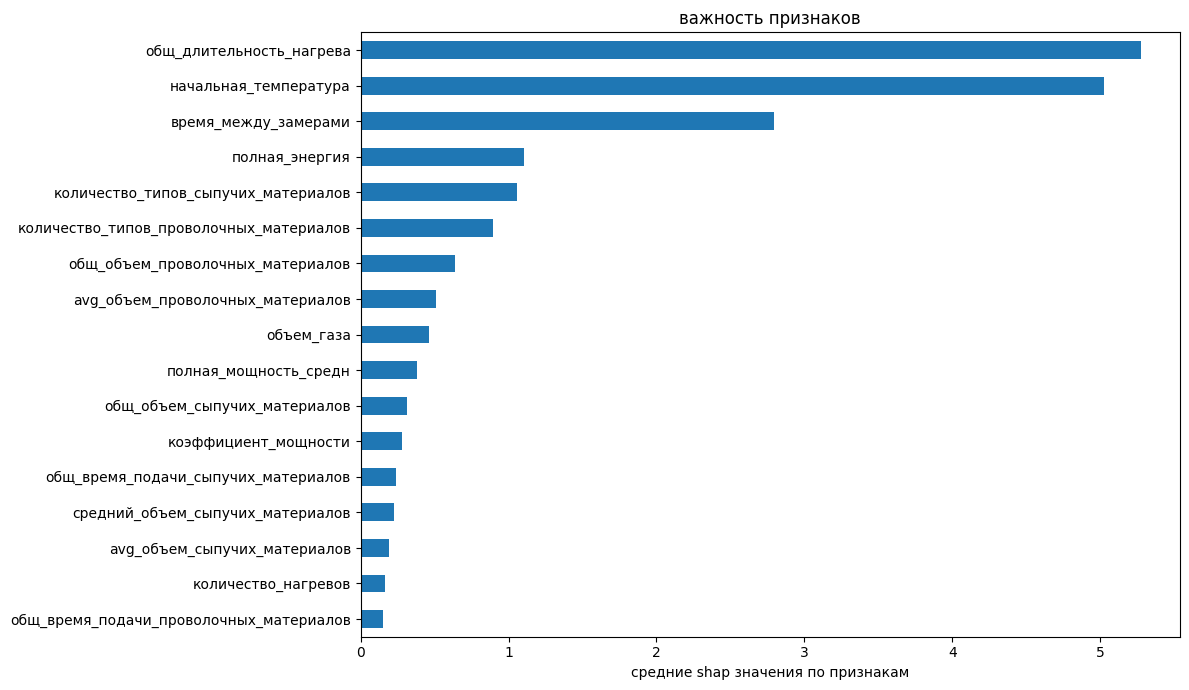

In [125]:
preprocessor = model_best.named_steps['preprocessor']

# кодирование и масштабирование признаков из тестовой выборки
X_test_conv = preprocessor.transform(X_test)

# нименования преобразованных признаков
columns = preprocessor.get_feature_names_out()

features = {}
for col in columns:
    if 'num__' in col:
        original_name = col.replace('num__', '')
    elif 'ohe__' in col:
        original_name = col.replace('ohe__', '')
        
        if '_' in original_name and original_name.split('_')[-1].isdigit():
            original_name = '_'.join(original_name.split('_')[:-1])
    else:
        original_name = col
    
    features[col] = original_name

# список исходных наименований признаков
original_feature_names = [features[col] for col in columns]


# shap значения
explainer = shap.TreeExplainer(model_best.named_steps['model'])
shap_values = explainer.shap_values(X_test_conv)

# датафрейм с исходными названиями
df = pd.DataFrame(
    shap_values[1] if isinstance(shap_values, list) else shap_values,
    columns=original_feature_names
)

# агрегация по исходным признакам
aggregated = df.T.groupby(level=0).sum().T

# график важности признаков
plt.figure(figsize=(12, 7))
aggregated.abs().mean().sort_values(ascending=True).plot(kind='barh')
plt.title('важность признаков')
plt.xlabel('средние shap значения по признакам')
plt.tight_layout()
plt.show()

### Исследованию самого важного признака

Построим график зависимости `общ_длительность_нагрева` от целевой переменной\
В качестве графика выберем диграмму рассеяния

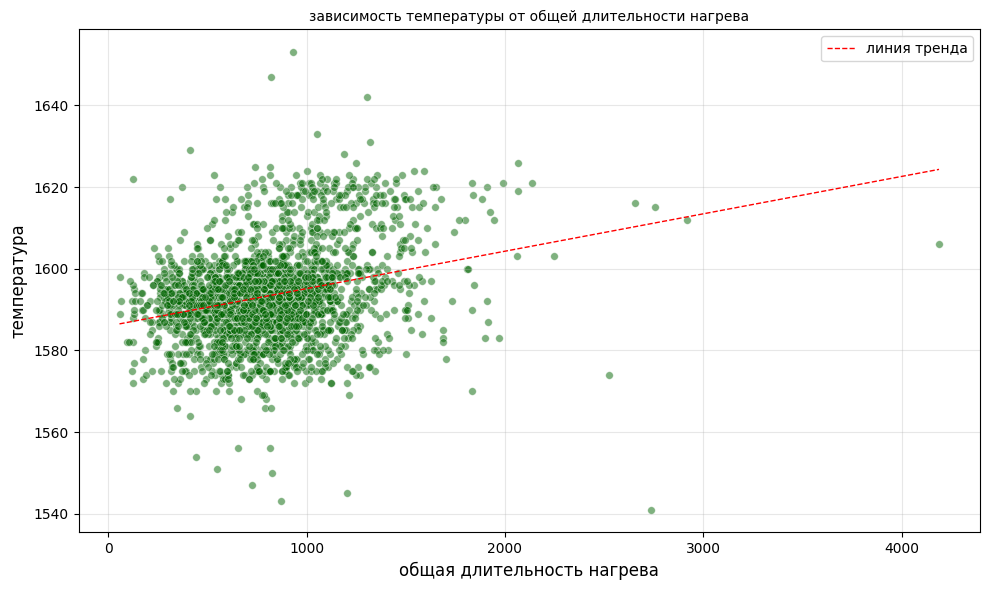

In [126]:
plt.figure(figsize=(10, 6))

# диаграмма рассеяния
plt.scatter(
    final_df['общ_длительность_нагрева'], 
    final_df['температура'],
    alpha=0.5,
    s=30,
    c='darkgreen',
    edgecolors='white',
    linewidth=0.5
)

plt.xlabel('общая длительность нагрева', fontsize=12)
plt.ylabel('температура', fontsize=12)
plt.title('зависимость температуры от общей длительности нагрева', fontsize=10)

# линия тренда
z = np.polyfit(final_df['общ_длительность_нагрева'], final_df['температура'], 1)
p = np.poly1d(z)
plt.plot(
    final_df['общ_длительность_нагрева'].sort_values(),
    p(final_df['общ_длительность_нагрева'].sort_values()),
    color='red',
    linestyle='--',
    linewidth=1,
    label='линия тренда'
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

По результатам проверки лучшей модели на тестовых данных:
1. проведена инициализация модели GBRegressor с лучшими параметрами. Значение метрики MAE составило 5.985;
2. Произведена визуализация важности признаков по результатам которой установлено, что самым важным оказался признак `начальная_температура`, далее `общ_длительность_нагрева` и `время_между_замерами`.
3. Построен график (диаграмма рассеяния) зависимости признака `общ_длительность_нагрева`  от целевой переменной (`температура`) по результатам визуализации которого наблюдается умеренная линейная зависимость между признаками.


## Выводы

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">


**Поставленная задача**\
Разработать модель МО, предсказывающую температуру сплава с целью уменьшения потребления электроэнергии на этапе обработки стали

**В процессе работы над проектом:**
1. Была проведена работа по изучению данных:
    - проведено подключение к БД (присутствуют все заявленные таблицы)
    - во всех таблицах, кроме ` data_arc` и ` data_gas` обнаружены пропуски
2. проведена предобработка данных по результатам которой:
    - тип данных столбцов `'Начало нагрева дугой', 'Конец нагрева дугой'` таблицы `data_arc` изменен на `datetime`;
    - тип данных столбцов `Bulk1 … Bulk15`  таблицы `data_bulk` изменен на `int`;
    - тип данных столбцов `Bulk1 … Bulk15, Wire 1 … Wire 9` таблиц ` data_bulk_time и data_wire_time` изменен на `datetime`;
    - тип данных столбца `Время замера` таблицы `data_temp` изменен на `datetime`;
    - тип данных столбца `Температура` таблицы `data_temp ` изменен на `int`;
    - тип данных столбцов ` Wire 1 … Wire 9` таблицы `data_wire` изменен на `float`;
    - после преобразований в данных не выявлено явных строк дубликатов.   

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

**3. По результатам исследовательского анализа таблиц:**
- Таблица **data_arc**:
    1. временной диапазон с 2019-07-05 по 2019-09-06
    2. заменено некорректное значение (отрицательное) в столбце Реактивная мощность на медианное значение всего столбца;
    3. в столбцах Активная мощность и Реактивная мощность присутствуют редкие выделяющиеся значения
    4. Созданы и визуализированы признаки: 
    	- времени нагрева в секундах (`длительность_нагрева`);
        - полной мощности (`полная_мощность`);
        - коэффициента мощности cos φ (`коэффициент_мощности`).
    5. Для корректной агрегации данных по партиям созданы признаки:
        - активная_энергия;
        - реактивная_энергия;
        - полная_энергия.
    6. - Проведена агрегация данных (создан датафрейм `data_arc_aggregated`) по партиям по результатам которой получены признаки:
    	- `количество_нагревов` - общее количество нагревов партии;
    	- `общ_длительность_нагрева` - общая длительность нагрева партии в секундах;
    	- `активная_мощность_средн` - средневзвешенная активная мощность партии с учетом всех нагревов
    	- `реактивная_мощность_средн` - средневзвешенная реактивная мощность партии с учетом всех нагревов
    	- `полная_мощность_средн` - средневзвешенная полная мощность партии с учетом всех нагревов
    	- ` активная_энергия ` - активная энергия, затраченная на все нагревы
    	- ` реактивная_энергия ` - реактивная энергия, затраченная на все нагревы
    	- ` полная_энергия ` - полная энергия, затраченная на все нагревы
    	- ` коэффициент_мощности ` - средний коэффициент мощности партии.

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">


Таблица **data_bulk**:
1. По результатам статистического анализа и визуализации распределения значений признаков установлено, что:
    - в данных присутствуют выделяющиеся значения (оставлены  без изменений, т.к. эти значения возможны в данном технологическом процессе);.

Таблица **data_bulk_time**:
1. По результатам проверки временных диапазонов каждого признака и соотнесения с временным диапазоном таблицы data_arc выявлено одно, выходящее за диапазон. Возможно, это связано с асинхронностью датчиков.
2. По результатам визуализации распределения диапазона времени между первой и последней подачей материалов по партиям в данных выявлены выделяющиеся значения превышающие 4000 с., что возможно из-за ошибок в данных или обусловлено длительным легированием партии.
3. Проведена агрегация данных (создан датафрейм `data_bulk_aggregated`) с образованием новых признаков:
	- `общ_объем_сыпучи_материалов` - общий объем сыпучих материалов по партиям;
	- `количество_типов_материалов` - количество типов материалов, добавленных в партию;
	- `общ_время_подачи_сыпучих_материалов` - диапазон времени между первой и последней подачей материалов по партиям в секундах (при использовании только одного типа материалов или при одновременном добавлении нескольких принято время подачи равное 1 минуте);
	- `avg_объем_сыпучих_материалов` - средний объем подачи сыпучих материалов в минуту.


Таблица **data_gas**:
1. По результатам визуализации распределения объема подаваемого газа выявлены выделяющиеся значения больше 40, вероятно это связано с большим количеством добавляемых материалов и, соответственно, большим количеством циклов продувки стали.

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

Таблица **data_temp**:
- По результатам статистического анализы выявлены пропущенные последние значения температуры у 739 партий (данные партии удалены из данных, т.к. заполнение пропусков повлияет на качество модели). 
- Удалены партии со значением температуры меньше 1500.
- Проведена агрегация данных (создан датафрейм `data_temp_aggregated`) с выделением целевой переменной (при агрегации выбраны партии, у которых не менее двух замеров температуры):
	- `начальная_температура` - первая измеренная температура;
    - **`температура` - последняя измеренная температура (целевая переменная)**;
    - `изменение_температуры` - изменение температуры между последним и первым замерами;
    - `время_между_замерами` - время между первым и последним измерением температуры в секунах.
- В датафрейме `data_temp_aggregated` 2475 партий.



Таблица **data_wire**:
- По результатам статистического анализа и визуализации распределения значений признаков установлено, что в данных присутствуют выделяющиеся значения.

Таблица data_wire_time:
1. По результатам проверки временных диапазонов каждого признака и соотнесения с временным диапазоном таблицы data_arc не выявлено значений, выходящих за диапазон
2. По результатам визуализации распределения диапазона времени между первой и последней подачей материалов по партиям в данных выявлены выделяющиеся значения превышающие 2000 с., что возможно из-за ошибок в данных или обусловлено длительным легированием партии.
3. Проведена агрегация данных (создан датафрейм `data_wire_aggregated`) с образованием новых признаков:
	- `общ_объем_проволочных_материалов` - общий объем проволочных материалов по партиям;
    - `количество_типов_проволочных_материалов` - количество типов проволочных материалов, добавленных в партию;
    - `общ_время_подачи_проволочных_материалов` - диапазон времени между первой и последней подачей материалов по партиям в секундах при использовании только одного типа материалов или при одновременном добавлении нескольких примем медианное время подачи для партии);
    - `avg_объем_проволочных_материалов` - средний объем подачи проволочных материалов в минуту.

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

4. Проведено объединение данных (создан датафрейм **final_df**):
    - Данные объединены только по партиям, присутствующим во всех таблицах (с учетом ТЗ *«во все партии точно добавлялись сыпучие и проволочные материалы, везде была выполнена продувка газом и сплав всегда нагревался»*). В объединенном датафрейме 2325 партий.

    - По результатам корреляционного анализа данных из датафрейма удалены коррелирующие признаки:
        - количество_замеров_температуры
        - активная_мощность_средн;
        - реактивная_мощность_средн;
        - активная_энергия;
        - реактивная_энергия.
    
    - По результатам исследовательского анализа данных установлено, что:
        - в данных обнаружены выделяющиеся значения (оставим их без изменений, т.к. проводили обработку на этапе поочередного исследования таблиц);
        - в признаке `изменение_температуры` обнаружены отрицательные значения, оставим их т.к. охлаждение является нормальным металлургического процесса; 
        - 27.5% партий подвергались нагреву 4 раза, 24% партий нагревались 5 раз, 16% партий нагревались 6 раз; 15% партий нагревались 3 раза;
        - в 47% партий добавлялось 4 типа сыпучих материалов, в 17% партий добавлялось 5 типов сыпучих материалов, в 16% партий 3 типа материалов, в 9% партий 1 тип сыпучего материала;
        - в 63% партий добавлялся 1 тип проволочных материалов, в 34% партий добавлялось 2 типа материалов, в 2,5% партий добавлялось 3 типа проволочных материалов.

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

5. Проведена подготовка данных для моделей МО:
- Написан пайплайн по масштабированию количественных признаков и кодированию категориальных;
    - количественные признаки: 
        - `начальная_температура`,
        - `изменение_температуры`,
        - `время_между_замерами`,
        - `общ_длительность_нагрева`, 
        - `полная_мощность_средн`,
        - `полная_энергия`,
        - `коэффициент_мощности`,
        - `общ_объем_сыпучих_материалов`,
        - `общ_время_подачи_сыпучих_материалов`,
        - `avg_объем_сыпучих_материалов`, 
        - `общ_объем_проволочных_материалов`, 
        - `общ_время_подачи_проволочных_материалов`,
        - `avg_объем_проволочных_материалов`, 
        - `объем_газа`.
    - категориальные признаки:
        - `количество_нагревов`, 
        - `количество_типов_сыпучих_материалов`,
        - `количество_типов_проволочных_материалов`
- Данные разделены на тренировочную и тестовую выборки в соотношении 75:25.

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

6. Проведено обучение моделей МО:
- Написана функция `objective_tree` по подбору гиперпараметров для моделей DecisionTreeRegressor, XGBRegressor.
- Написана функция `objective_neural_network` по подбору гиперпараметров для полносвязной нейросети:
    - для обучения нейросети написан класс `FeedForwardNN` и функция `training`
- Подбор лучших гиперпараметров проведен на основании значения метрики MAE при кроссвалидации с помощью библиотеки optuna;
- По результатам обучения моделей лушее значение метрики MAE при кроссвалидации показала XGBRegressor (6.309) (параметры модели выведены ниже)

In [127]:
# лучшие параметры XGBRegressor
params_xgb

,parameter,value
0,n_estimators,479.0000
1,max_depth,3.0000
2,learning_rate,0.0308
3,subsample,0.6383
4,colsample_bytree,0.9435
5,reg_alpha,0.0029
6,reg_lambda,0.0019
7,min_child_weight,3.0000
8,gamma,0.0017
9,max_leaves,108.0000


<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

7. Проведено тестирование лучше модели:
- Инициализирована модель GBRegressor с лучшими параметрами. Значение метрики MAE на тестовой выборке составило 5.985;
- Визуализирован график важности признаков по результатам которой установлено, что самым важным оказался признак `начальная_температура`, далее `общ_длительность_нагрева` и `время_между_замерами`.
- Построен график (диаграмма рассеяния) зависимости признака `общ_длительность_нагрева`  от целевой переменной (`температура`) по результатам визуализации которого наблюдается умеренная линейная зависимость между признаками.

<div class="alert alert-info" style="border-radius: 10px; box-shadow: 2px 2px 2px; border: 1px solid; padding: 10px ">

Для дальнейшего улучшения модели и сокращения затрат на производство:
- Можно синхронизировать датчики для отслеживания времени всех процессов и построения хронологии процесса (для лучшего контроля).
- Также улучшить контроль сбора данных (из данных пришлось удалить существенное количество партий, т.к. была не определена целевая переменная)
- По возможности добавить в данные больше партий с более редким добавлением сыпучих и проволочных материалов